# 1. 프로젝트 소개

- 연구 개요
    - 연구 목적: 러시아-우크라이나 전쟁이 한국 경제에 미치는 영향을 분석하여 향후 유사한 국제적 사건들에 대한 대응 전략을 수립하는데 기여하는 것
    - 분석기간: 2022/01/01 ~ 2024/10/31 (2022/02/24; 러우전쟁 발생)
- 데이터
    1. KOSPI INDEX: yfinance (Ticker: ^KS11)
    2. GPR Daily INDEX: https://www.matteoiacoviello.com/gpr.htm
    3. USD/KRW Exchange Rate: yfinance (Ticker: KRW=X)
    4. WTI Future Price: yfinance (Ticker: CL=F)
    5. Aluminum Future Price: yfinance (Ticker: ALI=F)

- 분석 과정
    - 국내 증시를 대표하는 KOSPI 지수를 종속변수로 설정하고, 전쟁의 심각도를 반영하는 GPR INDEX, 원달러환율(USD/KRW), 그리고 국제 유가(WTI 원유 선물)과 원자재(알루미늄 선물) 가격을 독립변수로 선정

# 2. 라이브러리

In [1]:
import sys
import subprocess

# 1. 설치할 패키지 명과 실제 임포트 명 매핑 (다를 경우를 대비)
packages = {
    "yfinance": "yfinance",
    "pandas": "pandas",
    "numpy": "numpy",
    "seaborn": "seaborn",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "scikit-learn": "sklearn",
    "statsmodels": "statsmodels"
}

# 2. 패키지 확인 및 자동 설치
for pip_name, import_name in packages.items():
    try:
        __import__(import_name)
    except ImportError:
        print(f"[{pip_name}] 패키지가 없어 설치를 진행합니다...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
            print(f"[{pip_name}] 설치 완료.")
        except Exception as e:
            print(f"[{pip_name}] 설치 중 오류 발생: {e}")

# 3. 라이브러리 임포트
from datetime import datetime
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 분석 및 통계/머신러닝 패키지
import statsmodels.api as sm
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.api import VAR
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller

print("모든 패키지가 성공적으로 로드되었습니다.")

모든 패키지가 성공적으로 로드되었습니다.


# 3. 데이터로드

#### 1. KOSPI INDEX

In [2]:
# 1. 데이터 로드
KOSPI = yf.download("^KS11", start="2022-01-01", end="2024-10-31")
display(KOSPI.head())

# 2. 데이터프레임 레이아웃 다듬기
KOSPI.columns = KOSPI.columns.droplevel(1) # Ticker Header drop
# KOSPI.index = pd.to_datetime(KOSPI.index).date 
# KOSPI.index = pd.to_datetime(KOSPI.index) # 과거 Date column에 시간정보 포함되어있었을 때 처리

KOSPI.index.name = "Date"
KOSPI.columns.name = None
display(KOSPI.head())

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^KS11,^KS11,^KS11,^KS11,^KS11
Date,,,,,
2022-01-04,2989.239990,2995.250000,2973.080078,2991.969971,621200
2022-01-05,2953.969971,2986.199951,2936.729980,2984.050049,786900
2022-01-06,2920.530029,2952.540039,2915.379883,2925.399902,785500
2022-01-07,2954.889893,2959.030029,2933.100098,2933.780029,545800
2022-01-10,2926.719971,2951.120117,2910.899902,2947.370117,477000


,Close,High,Low,Open,Volume
Date,,,,,
2022-01-04,2989.239990,2995.250000,2973.080078,2991.969971,621200
2022-01-05,2953.969971,2986.199951,2936.729980,2984.050049,786900
2022-01-06,2920.530029,2952.540039,2915.379883,2925.399902,785500
2022-01-07,2954.889893,2959.030029,2933.100098,2933.780029,545800
2022-01-10,2926.719971,2951.120117,2910.899902,2947.370117,477000


#### 2. GPR Daily INDEX

In [3]:
# 1. 데이터 로드
data = pd.read_excel("../data/data_gpr_daily_recent.xlsx")
display(data.head())

# 2. 데이터프레임 레이아웃 다듬기
data['DAY'] = pd.to_datetime(data['DAY'], format='%Y%m%d')          # int -> datetime
start_date = '2022-01-01'
end_date = '2024-10-31'
GPR = data[(data['DAY'] >= start_date) & (data['DAY'] <= end_date)] # 분석기간만 left

GPR = GPR.rename(columns={'DAY': 'Date'})
GPR = GPR.set_index('Date')
display(GPR.head())

,DAY,N10D,GPRD,GPRD_ACT,GPRD_THREAT,date,GPRD_MA30,GPRD_MA7,event,var_name,var_label
0,19850101,216,230.039429,275.197601,153.027985,1985-01-01,230.039429,230.039429,NaN,DAY,DAY
1,19850102,315,115.676971,146.772064,87.444572,1985-01-02,172.858200,172.858200,NaN,N10D,"Number of articles (10 recent newspapers, 1985-)"
2,19850103,374,97.428459,158.937653,29.459934,1985-01-03,147.714951,147.714951,NaN,GPRD,Daily GPR (Index: 1985:2019=100)
3,19850104,421,157.366638,156.882248,157.026352,1985-01-04,150.127869,150.127869,NaN,GPRD_ACT,Daily GPR Acts (Index: 1985:2019=100)
4,19850105,285,81.361313,92.698143,77.319405,1985-01-05,136.374557,136.374557,NaN,GPRD_THREAT,Daily GPR Threats (Index: 1985:2019=100)


,N10D,GPRD,GPRD_ACT,GPRD_THREAT,date,GPRD_MA30,GPRD_MA7,event,var_name,var_label
Date,,,,,,,,,,
2022-01-01,420,63.096531,31.451157,91.816795,2022-01-01,99.514793,72.327545,NaN,NaN,NaN
2022-01-02,350,37.857918,0.000000,62.960087,2022-01-02,97.237656,71.488632,NaN,NaN,NaN
2022-01-03,443,52.343060,14.909126,74.614098,2022-01-03,96.538544,67.698975,NaN,NaN,NaN
2022-01-04,633,88.963112,10.434032,139.248215,2022-01-04,96.612053,71.995125,NaN,NaN,NaN
2022-01-05,721,96.482552,82.444771,137.534164,2022-01-05,95.809982,80.365654,NaN,NaN,NaN


| Column          | 설명                                             
| --------------- | ---------------------------------------------- 
| **DAY**         | 관측일(Date)                                      
| **N10D**        | GPR 산출에 사용된 10개 주요 신문 기사 수(News Count)         
| **GPRD**        | 일별 지정학적 리스크 지수(Geopolitical Risk Index, Daily) 
| **GPRD_ACT**    | 지정학적 사건(전쟁·테러 등) 관련 기사 기반의 GPR 지수           
| **GPRD_THREAT** | 지정학적 위협(긴장 고조·갈등 가능성) 관련 기사 기반의 GPR 지수         
| **date**        | 날짜 형식으로 변환된 관측일(datetime)                      
| **GPRD_MA30**   | GPRD의 30일 이동평균(Moving Average)                 
| **GPRD_MA7**    | GPRD의 7일 이동평균(Moving Average)                 
| **event**       | 주요 지정학적 이벤트 발생 여부를 나타내는 변수(예: 0=평상시, 1=이벤트 발생) 

#### 3. USD/KRW Exchange Rate

In [4]:
# 1. 데이터 로드
usd_krw = yf.download("KRW=X", start="2022-01-01", end="2024-10-31")
display(usd_krw.head())

# 2. 데이터프레임 레이아웃 다듬기
usd_krw.columns = usd_krw.columns.droplevel(1) # Ticker header drop

usd_krw.index.name = "Date"
usd_krw.columns.name = None
display(usd_krw.head())

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,KRW=X,KRW=X,KRW=X,KRW=X,KRW=X
Date,,,,,
2022-01-03,1187.780029,1195.339966,1187.000000,1187.130005,0
2022-01-04,1194.680054,1199.729980,1191.500000,1195.630005,0
2022-01-05,1196.500000,1199.689941,1193.280029,1196.670044,0
2022-01-06,1199.250000,1206.260010,1196.589966,1199.250000,0
2022-01-07,1205.780029,1204.760010,1199.579956,1204.670044,0


,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,1187.780029,1195.339966,1187.000000,1187.130005,0
2022-01-04,1194.680054,1199.729980,1191.500000,1195.630005,0
2022-01-05,1196.500000,1199.689941,1193.280029,1196.670044,0
2022-01-06,1199.250000,1206.260010,1196.589966,1199.250000,0
2022-01-07,1205.780029,1204.760010,1199.579956,1204.670044,0


#### 4. WTI Crude Oil Futures

In [5]:
# 1. 데이터 로드
wti_crude = yf.download("CL=F", start="2022-01-01", end="2024-10-31")
display(wti_crude.head())

# 2. 데이터프레임 레이아웃 다듬기
wti_crude.columns = wti_crude.columns.droplevel(1)  # 열의 Ticker 레벨 제거

wti_crude.index.name = "Date"
wti_crude.columns.name = None
display(wti_crude.head())

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2022-01-03,76.080002,76.459999,74.269997,75.690002,317628
2022-01-04,76.989998,77.639999,75.699997,76.019997,372848
2022-01-05,77.849998,78.580002,76.510002,77.180000,397898
2022-01-06,79.459999,80.239998,76.730003,77.239998,476665
2022-01-07,78.900002,80.470001,78.519997,79.620003,414434


,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,76.080002,76.459999,74.269997,75.690002,317628
2022-01-04,76.989998,77.639999,75.699997,76.019997,372848
2022-01-05,77.849998,78.580002,76.510002,77.180000,397898
2022-01-06,79.459999,80.239998,76.730003,77.239998,476665
2022-01-07,78.900002,80.470001,78.519997,79.620003,414434


#### 5. Aluminum Futures

In [6]:
# 1. 데이터 로드
aluminum = yf.download("ALI=F", start="2022-01-01", end="2024-10-31")
display(aluminum.head())

# 2. 데이터프레임 레이아웃 다듬기
aluminum.columns = aluminum.columns.droplevel(1)  # 열의 Ticker 레벨 제거

aluminum.index.name = "Date"
aluminum.columns.name = None
display(aluminum.head())

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,ALI=F,ALI=F,ALI=F,ALI=F,ALI=F
Date,,,,,
2022-01-03,2752.50,2752.50,2752.50,2752.50,0
2022-01-04,2802.75,2802.75,2802.75,2802.75,0
2022-01-05,2876.00,2876.00,2876.00,2876.00,0
2022-01-06,2890.00,2890.00,2890.00,2890.00,0
2022-01-07,2884.50,2884.50,2884.50,2884.50,0


,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,2752.50,2752.50,2752.50,2752.50,0
2022-01-04,2802.75,2802.75,2802.75,2802.75,0
2022-01-05,2876.00,2876.00,2876.00,2876.00,0
2022-01-06,2890.00,2890.00,2890.00,2890.00,0
2022-01-07,2884.50,2884.50,2884.50,2884.50,0


#### 6. Merging data

In [7]:
# 종가 기준 병합 (GPR은 원Index 기준)
dfs = [KOSPI[['Close']], GPR[['GPRD']], usd_krw[['Close']], wti_crude[['Close']], aluminum[['Close']]] # 데이터프레임 리스트
merged_data = pd.concat(dfs, axis=1, join='inner') # 공통 index 기준 병합
merged_data.columns = ['KOSPI', 'GPR', 'USD', 'WTI', 'Aluminum']
display(merged_data)

,KOSPI,GPR,USD,WTI,Aluminum
Date,,,,,
2022-01-04,2989.239990,88.963112,1194.680054,76.989998,2802.75
2022-01-05,2953.969971,96.482552,1196.500000,77.849998,2876.00
2022-01-06,2920.530029,70.014641,1199.250000,79.459999,2890.00
2022-01-07,2954.889893,118.959610,1205.780029,78.900002,2884.50
2022-01-10,2926.719971,130.006577,1196.880005,78.230003,2898.75
...,...,...,...,...,...
2024-10-24,2581.030029,144.623535,1377.339966,70.190002,2597.25
2024-10-25,2583.270020,206.229889,1376.319946,71.779999,2629.00
2024-10-28,2612.429932,153.224503,1387.660034,67.379997,2590.50


# 4. EDA

#### 1. 개별 변수 탐색

In [8]:
# 요약 통계량 탐색
# 1. info
merged_data.info() # 결측값 없음

# 2. describe
merged_data.describe() # 분포 특이사항 없음

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 667 entries, 2022-01-04 to 2024-10-30
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   KOSPI     667 non-null    float64
 1   GPR       667 non-null    float64
 2   USD       667 non-null    float64
 3   WTI       667 non-null    float64
 4   Aluminum  667 non-null    float64
dtypes: float64(5)
memory usage: 31.3 KB


,KOSPI,GPR,USD,WTI,Aluminum
count,667.000000,667.000000,667.000000,667.000000,667.000000
mean,2554.152896,151.640071,1314.714740,83.253853,2447.218516
std,153.101332,62.007861,54.624749,11.805373,343.441537
min,2155.489990,36.468636,1185.880005,65.750000,2073.250000
25%,2443.939941,114.240936,1288.325012,75.280003,2211.375000
50%,2564.280029,141.321152,1318.349976,80.089996,2354.500000
75%,2666.955078,175.418945,1347.954956,87.830002,2515.625000
max,2989.239990,523.524658,1443.959961,123.699997,3873.000000


- 각 변수들의 단위가 일치하지 않아 스케일 차이가 존재함 (정규화/표준화의 필요성)
- KOSPI 지수와 원달러환율은 대칭적인 분포를 가짐
- GPR 지수는 좌측으로 살짝 치우친 분포 가지며, 분석기간동안 극단적으로 큰 지수 값 존재함
- WTI 원유 선물은 우측으로 살짝 치우친 분포를 가짐
- 알루미늄 선물은 우측으로 치우친 분포를 가지며, 분석기간동안 극단적으로 큰 가격 값 존재함


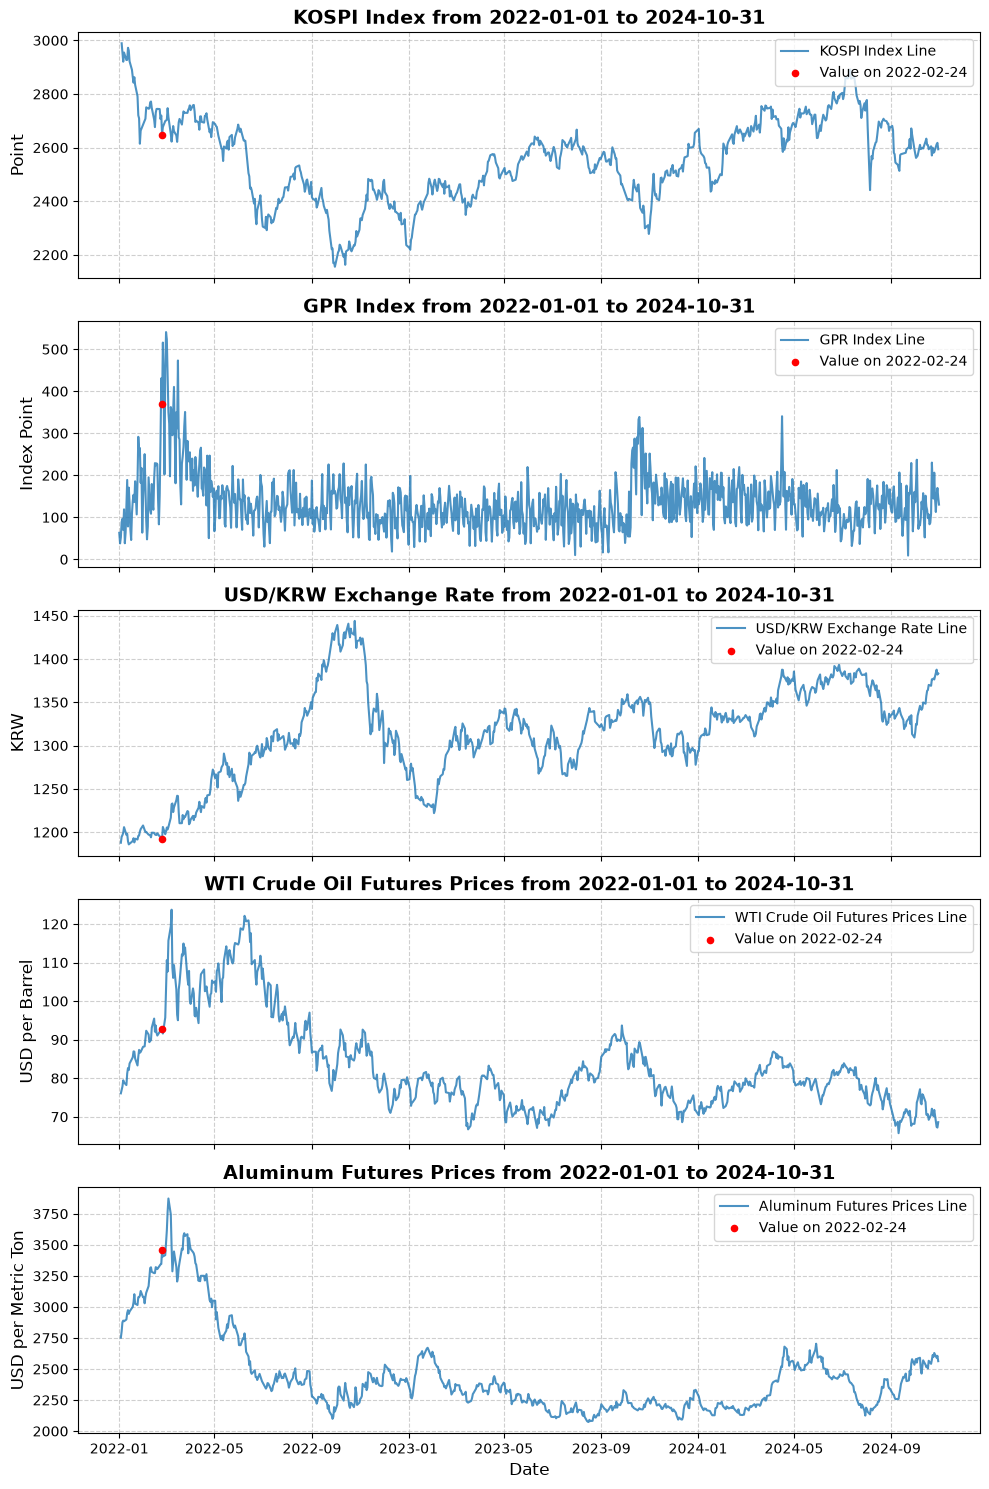

In [9]:
# 5개 변수 가격 기간별 추이 시각화
# 1. 시각화할 데이터셋 정보 정의 (변수명, 컬럼명, 타이틀, Y축 라벨)
plot_configs = [
    (KOSPI, "Close", "KOSPI Index", "Point"),
    (GPR, "GPRD", "GPR Index", "Index Point"),
    (usd_krw, "Close", "USD/KRW Exchange Rate", "KRW"),
    (wti_crude, "Close", "WTI Crude Oil Futures Prices", "USD per Barrel"),
    (aluminum, "Close", "Aluminum Futures Prices", "USD per Metric Ton")
]

# 2. 서브플롯 생성
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 15), sharex=True)
highlight_date = pd.to_datetime("2022-02-24")

# 3. 개별 플롯 생성
for ax, (df, col, title, ylabel) in zip(axes, plot_configs):
    # 선 그래프
    ax.plot(df.index, df[col], label=f"{title} Line", alpha=0.8) 
    
    # 러우전쟁 발발일(2022-02-24) 빨간점 표시
    if highlight_date in df.index:
        highlight_price = df.loc[highlight_date, col]
        ax.scatter(highlight_date, highlight_price, color="red", s=20, zorder=5,
                   label=f"Value on {highlight_date.date()}")
    
    # 그래프 스타일 설정
    ax.set_title(f"{title} from 2022-01-01 to 2024-10-31", fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(loc="upper right", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.6)

# 4. X축 라벨 표시 (bottom)
axes[-1].set_xlabel("Date", fontsize=12)

# 5. 플롯 간 간격 조절 및 출력
plt.tight_layout()
plt.show()

- 러우전쟁 발발일 2022/02/24를 기준으로 5개 변수는 모두 급등 혹은 급락의 변화를 겪음

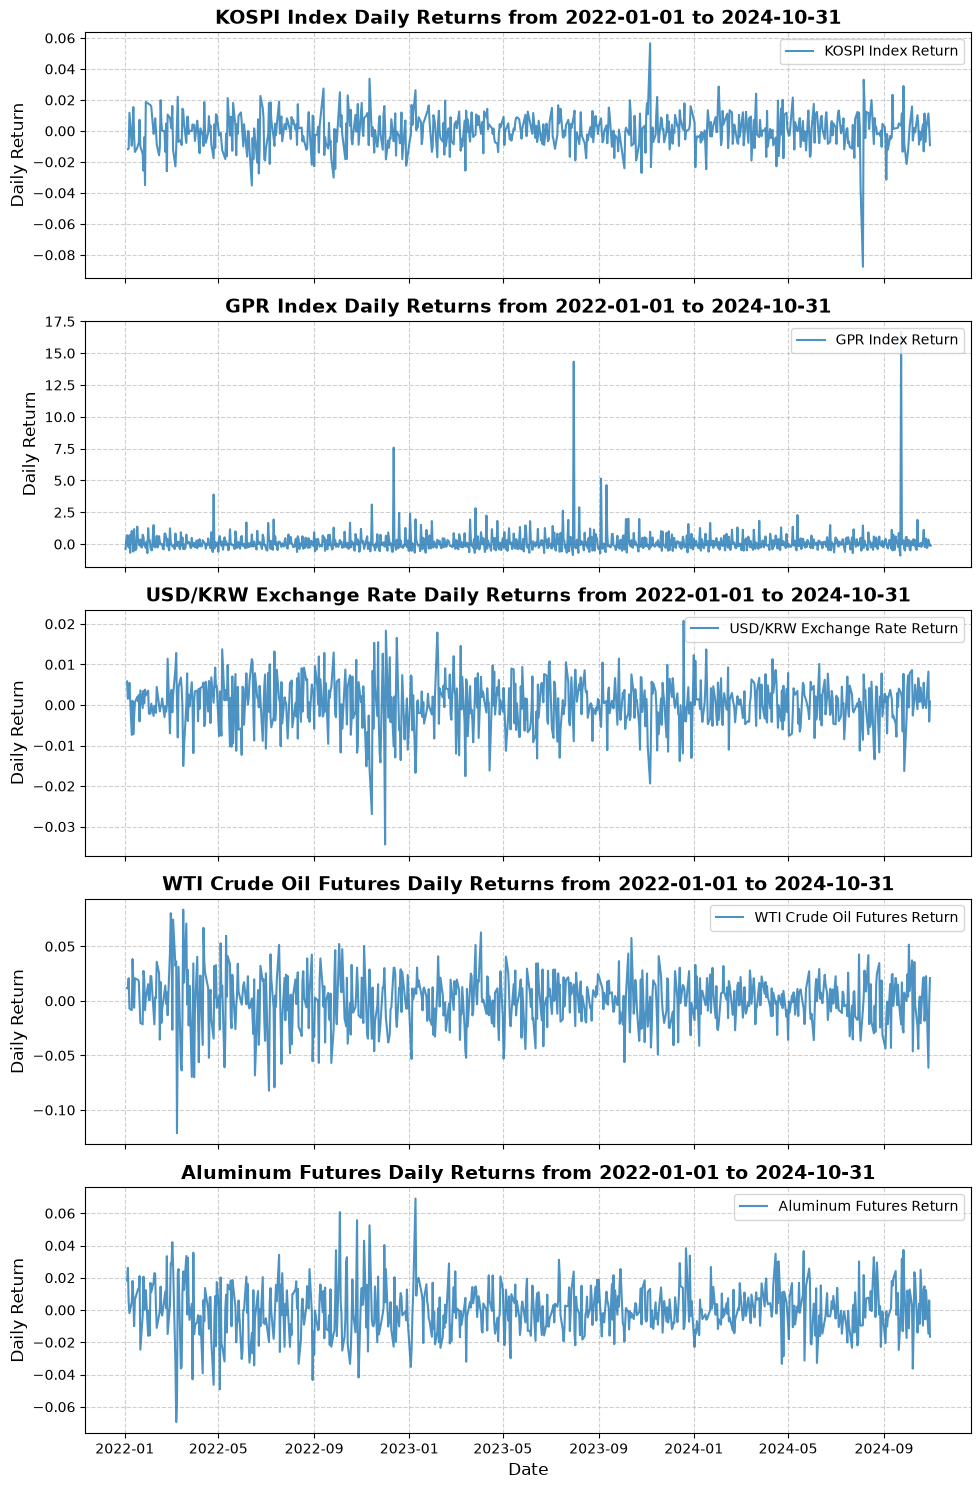

In [10]:
# 5개 변수 가격 변동성 기간별 추이 시각화

# 1. 시각화할 데이터셋 정보 정의 (변수명, 컬럼명, 타이틀, Y축 라벨)
# GPR의 경우 원본 컬럼명이 'GPRD'이므로 이를 반영하여 매핑합니다.
volatility_configs = [
    (KOSPI, "Close", "KOSPI Index", "Daily Return"),
    (GPR, "GPRD", "GPR Index", "Daily Return"),
    (usd_krw, "Close", "USD/KRW Exchange Rate", "Daily Return"),
    (wti_crude, "Close", "WTI Crude Oil Futures", "Daily Return"),
    (aluminum, "Close", "Aluminum Futures", "Daily Return")
]

# 2. 서브플롯 생성
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 15), sharex=True)
highlight_date = pd.to_datetime("2022-02-24")

# 3. 개별 플롯 생성
for ax, (df, col, title, ylabel) in zip(axes, volatility_configs):
    # 일간 변동성(수익률) 계산
    daily_returns = df[col].pct_change()
    
    # 선 그래프
    ax.plot(daily_returns.index, daily_returns, label=f"{title} Return", alpha=0.8)
    
    # 그래프 스타일 설정
    ax.set_title(f"{title} Daily Returns from 2022-01-01 to 2024-10-31", fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(loc="upper right", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.6)

# 4. X축 라벨 표시 (bottom)
axes[-1].set_xlabel("Date", fontsize=12)

# 5. 플롯 간 간격 조절 및 출력
plt.tight_layout()
plt.show()

- GPR 지수는 변동이 비정상적으로 커지는 시기가 있는 것을 확인
- 나머지 변수에서는 일반 시계열 데이터의 변동성 양상이 나타남

#### 2. KOSPI 지수 vs. 나머지 변수 탐색

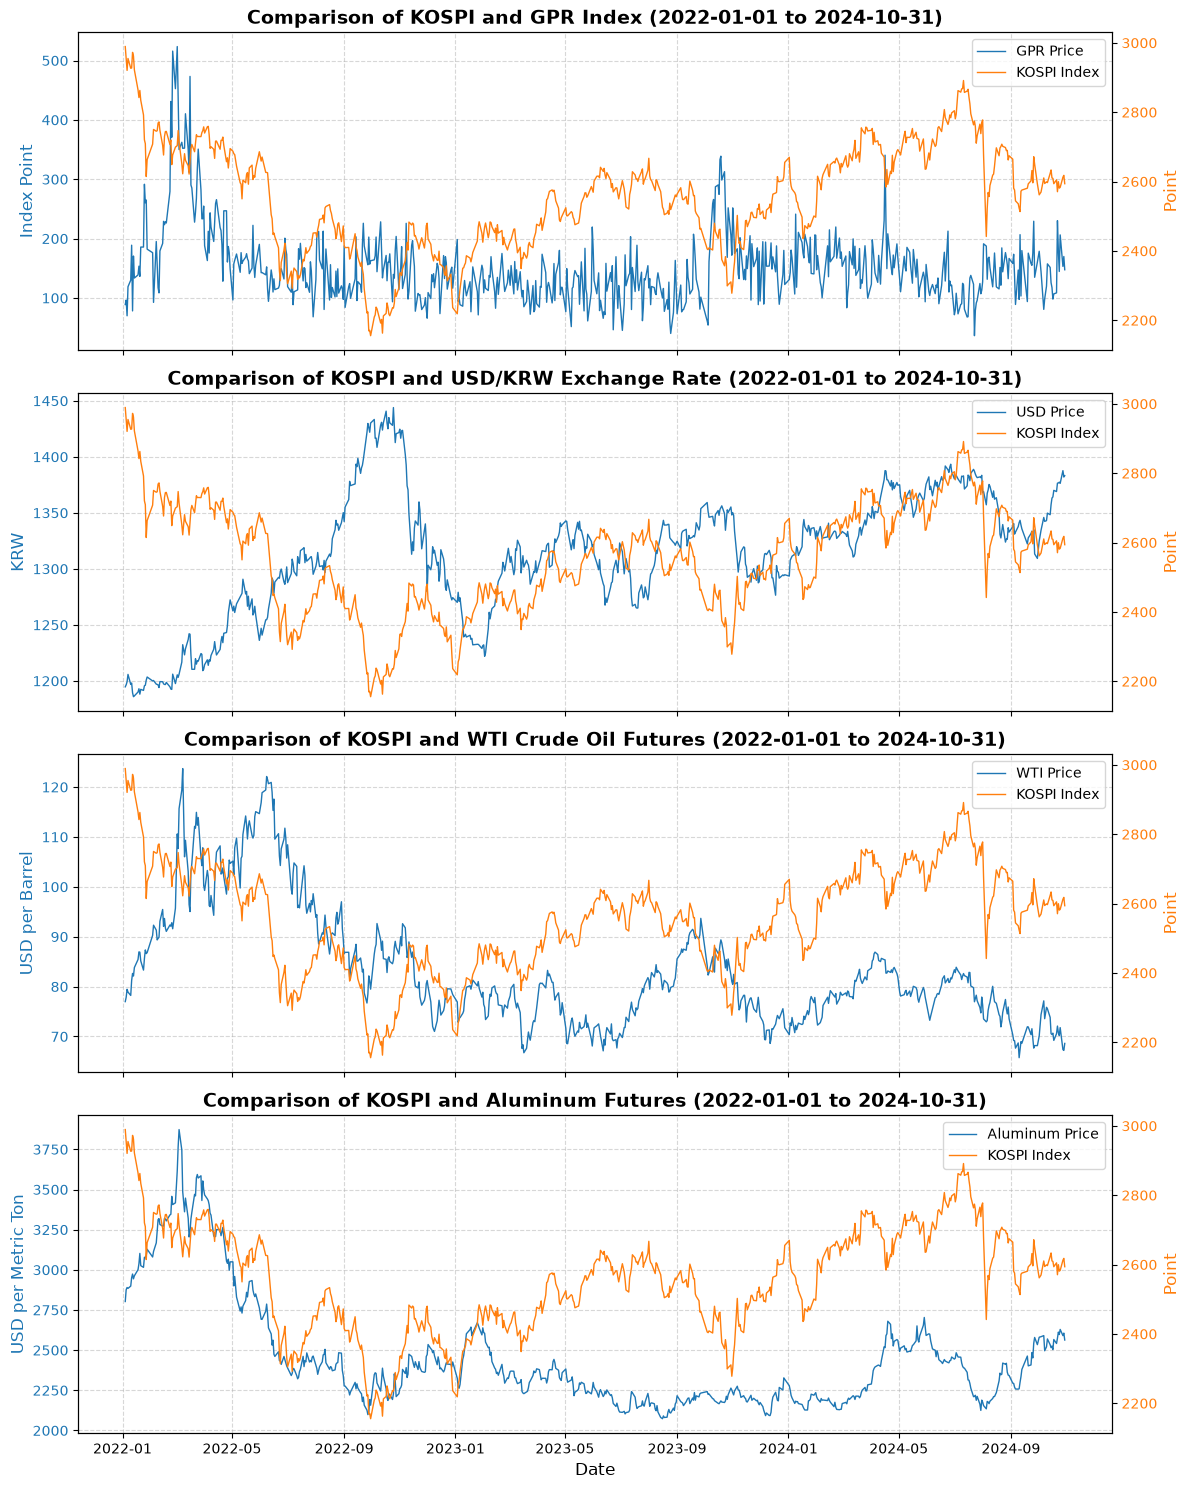

In [11]:
# KOSPI와 주요 변수 간의 이중 Y축 비교 시각화
# 1. 시각화할 데이터셋 정보 정의 (비교할 컬럼명, 타이틀, 왼쪽 Y축 라벨)
comparison_configs = [
    ('GPR', 'GPR Index', 'Index Point'),
    ('USD', 'USD/KRW Exchange Rate', 'KRW'),
    ('WTI', 'WTI Crude Oil Futures', 'USD per Barrel'),
    ('Aluminum', 'Aluminum Futures', 'USD per Metric Ton') # 기존 오타(USE -> USD) 수정
]

# 2. 서브플롯 생성
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 15), sharex=True)

# 3. 개별 플롯 생성
for ax1, (col, title, ylabel) in zip(axes, comparison_configs):
    # 타겟 데이터 (GPR, USD, WTI, Aluminum): 왼쪽 Y축
    line1 = ax1.plot(merged_data.index, merged_data[col], label=f'{col} Price', color='tab:blue', linewidth=1)
    ax1.set_ylabel(ylabel, color='tab:blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    
    # KOSPI 데이터: 오른쪽 Y축 공유
    ax2 = ax1.twinx()
    line2 = ax2.plot(merged_data.index, merged_data['KOSPI'], label='KOSPI Index', color='tab:orange', linewidth=1)
    ax2.set_ylabel('Point', color='tab:orange', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    
    # 범례 합치기
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', fontsize=10)
    
    # 그래프 스타일 설정
    ax1.set_title(f'Comparison of KOSPI and {title} (2022-01-01 to 2024-10-31)', fontsize=14, fontweight='bold')
    ax1.grid(True, linestyle="--", alpha=0.5)

# 4. X축 라벨 표시 (bottom)
axes[-1].set_xlabel('Date', fontsize=12)

# 5. 플롯 간 간격 조절 및 출력
plt.subplots_adjust(hspace=0.3)
plt.tight_layout()
plt.show()

- 원달러환율은 KOSPI 지수와 서로 반대방향으로 움직이는 양상 존재함
- WTI 원유 선물은 KOSPI 지수에 후행하는 움직임 존재함

# 5. 데이터 전처리

#### 1. 가격→수익률 변환 검토

<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\s'
C:\Users\user\AppData\Local\Temp\ipykernel_24792\123295097.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x, p, 'k', linewidth=2, label=f'Normal fit ($\mu$={mu:.2f}, $\sigma$={std:.2f})')
C:\Users\user\AppData\Local\Temp\ipykernel_24792\123295097.py:27: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(x, p, 'k', linewidth=2, label=f'Normal fit ($\mu$={mu:.2f}, $\sigma$={std:.2f})')


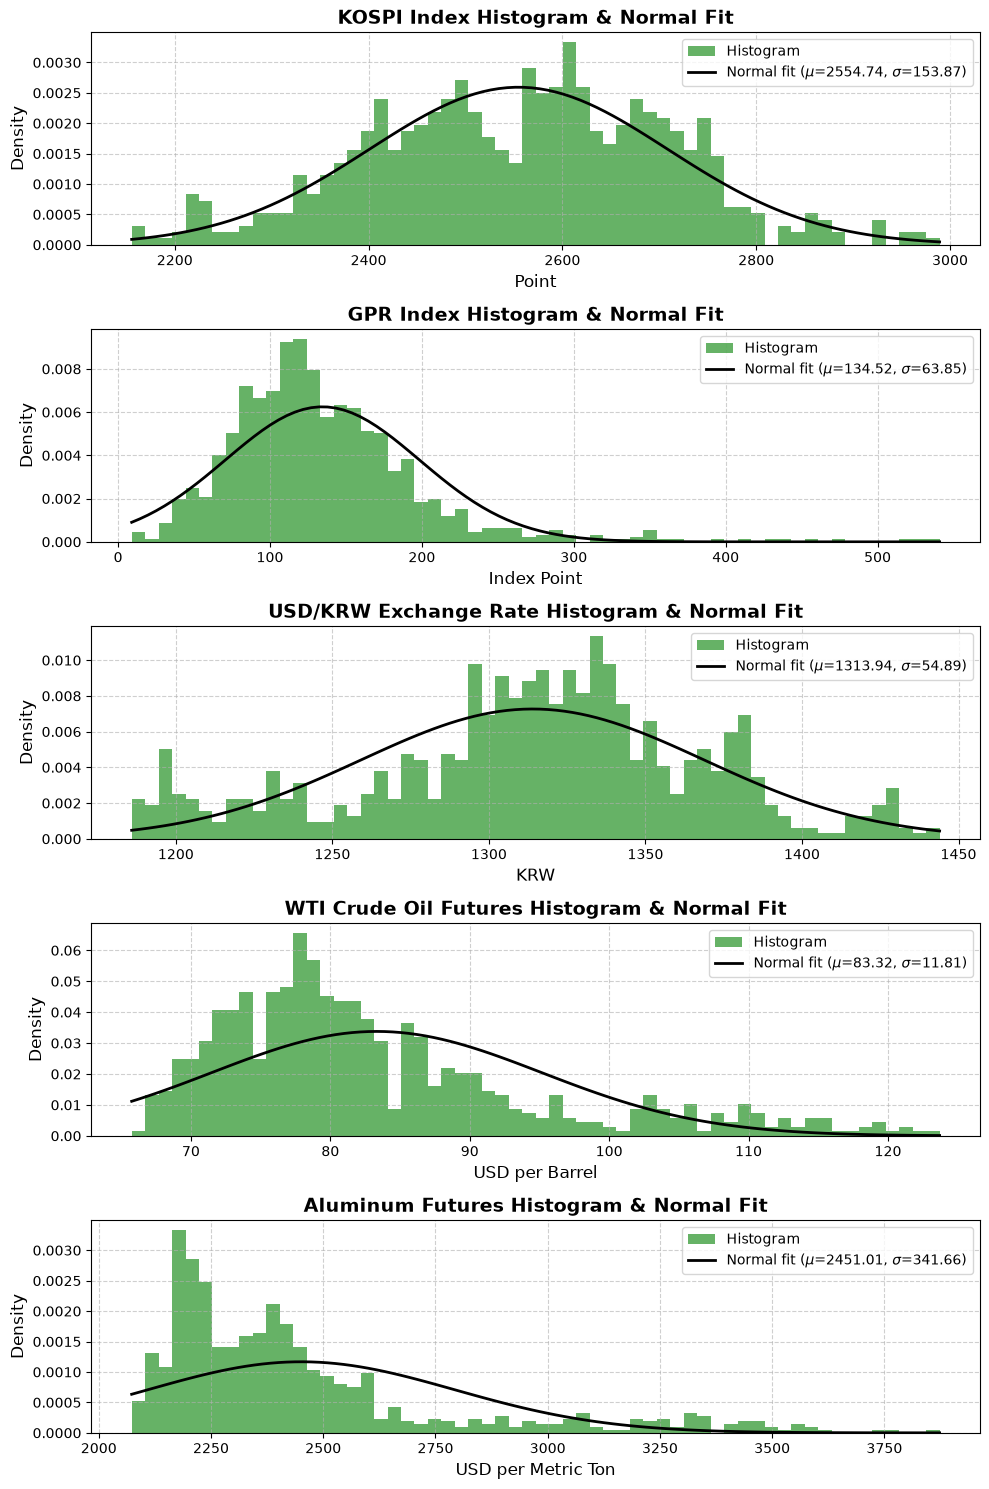

In [12]:
# 각 변수의 히스토그램과 정규분포 곡선 확인
# 1. 시각화할 데이터셋 정보 정의 (변수명, 컬럼명, 타이틀, X축 라벨)
dist_configs = [
    (KOSPI, "Close", "KOSPI Index", "Point"),
    (GPR, "GPRD", "GPR Index", "Index Point"),
    (usd_krw, "Close", "USD/KRW Exchange Rate", "KRW"),
    (wti_crude, "Close", "WTI Crude Oil Futures", "USD per Barrel"),
    (aluminum, "Close", "Aluminum Futures", "USD per Metric Ton")
]

# 2. 서브플롯 생성
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 15))

# 3. 개별 플롯 생성
for ax, (df, col, title, xlabel) in zip(axes, dist_configs):
    values = df[col]
    
    # 히스토그램 그리기
    count, bins, _ = ax.hist(values, bins=60, density=True, alpha=0.6, color='g', label='Histogram')
    
    # 정규분포 곡선 피팅
    mu, std = norm.fit(values)
    x = np.linspace(bins.min(), bins.max(), 100)
    p = norm.pdf(x, mu, std)
    
    # 피팅 라인 추가
    ax.plot(x, p, 'k', linewidth=2, label=f'Normal fit ($\mu$={mu:.2f}, $\sigma$={std:.2f})')
    
    # 그래프 스타일 설정
    ax.set_title(f'{title} Histogram & Normal Fit', fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.6)

# 4. 플롯 간 간격 조절 및 출력
plt.tight_layout()
plt.show()

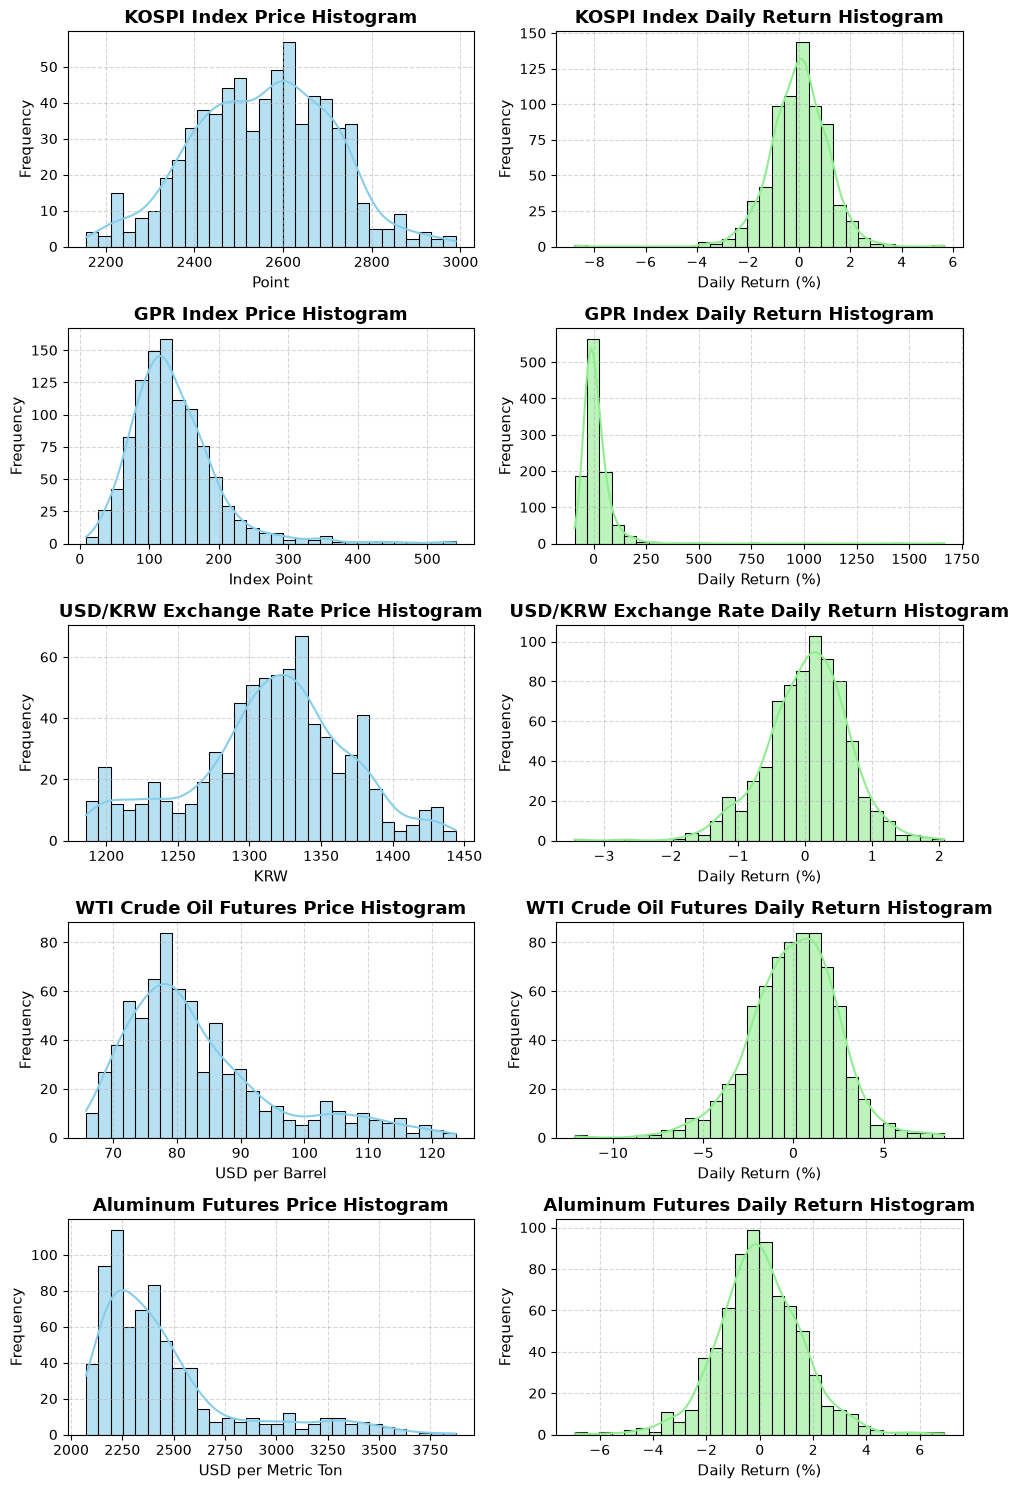

In [13]:
# 가격(지수) 데이터와 수익률 데이터의 히스토그램 비교

# 1. 시각화할 데이터셋 정보 정의 (변수명, 컬럼명, 타이틀, 가격 단위 라벨)
comparison_dist_configs = [
    (KOSPI, "Close", "KOSPI Index", "Point"),
    (GPR, "GPRD", "GPR Index", "Index Point"),
    (usd_krw, "Close", "USD/KRW Exchange Rate", "KRW"),
    (wti_crude, "Close", "WTI Crude Oil Futures", "USD per Barrel"),
    (aluminum, "Close", "Aluminum Futures", "USD per Metric Ton")
]

# 2. 서브플롯 생성
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 15))

# 3. 개별 플롯 생성
for (ax_price, ax_returns), (df, col, title, price_unit) in zip(axes, comparison_dist_configs):
    # 데이터 추출 및 일간 수익률(%) 계산
    price_data = df[col]
    daily_returns = price_data.pct_change() * 100

    # [왼쪽 열] 원본 가격 히스토그램 및 KDE
    sns.histplot(price_data, kde=True, color='skyblue', bins=30, ax=ax_price, alpha=0.6)
    ax_price.set_title(f'{title} Price Histogram', fontsize=13, fontweight='bold')
    ax_price.set_xlabel(price_unit, fontsize=11)
    ax_price.set_ylabel('Frequency', fontsize=11)
    ax_price.grid(True, linestyle="--", alpha=0.5)

    # [오른쪽 열] 수익률 히스토그램 및 KDE
    sns.histplot(daily_returns, kde=True, color='lightgreen', bins=30, ax=ax_returns, alpha=0.6)
    ax_returns.set_title(f'{title} Daily Return Histogram', fontsize=13, fontweight='bold')
    ax_returns.set_xlabel('Daily Return (%)', fontsize=11)
    ax_returns.set_ylabel('Frequency', fontsize=11)
    ax_returns.grid(True, linestyle="--", alpha=0.5)

# 4. 플롯 간 간격 조절 및 출력
plt.tight_layout()
plt.show()

- KOSPI 지수는 정규분포를 따름
- GPR 지수, WTI 원유 선물, 알루미늄 선물에서는 오른쪽으로 꼬리가 긴 분포 나타남
- 원달러 환율은 정규분포보다 꼬리가 얇고 중심점이 뾰족한 분포 나타남

- 수익률로 변환하였을 때, 변수들의 분포가 안정적으로 정규분포 형태를 띄게 됨.
- 시계열적인 특성이나 이벤트를 과소 축소할 가능성이 있어 수익률로 변환하지 않음.

#### 2. 표준화 진행

In [14]:
# 가격(지수) 데이터의 표준화 가능성
tmp=merged_data.copy()
scaler = StandardScaler()

scaled_data_tmp=scaler.fit_transform(tmp)

scaled_data=pd.DataFrame(scaled_data_tmp,columns=tmp.columns, index=tmp.index)
scaled_data

,KOSPI,GPR,USD,WTI,Aluminum
Date,,,,,
2022-01-04,2.843957,-1.011549,-2.199091,-0.530992,1.035979
2022-01-05,2.613414,-0.890192,-2.165748,-0.458089,1.249422
2022-01-06,2.394833,-1.317360,-2.115367,-0.321608,1.290216
2022-01-07,2.619427,-0.527433,-1.995734,-0.369079,1.274190
2022-01-10,2.435293,-0.349145,-2.158786,-0.425876,1.315713
...,...,...,...,...,...
2024-10-24,0.175683,-0.113241,1.147323,-1.107433,0.437175
2024-10-25,0.190325,0.881030,1.128636,-0.972647,0.529691
2024-10-28,0.380929,0.025571,1.336391,-1.345639,0.417506


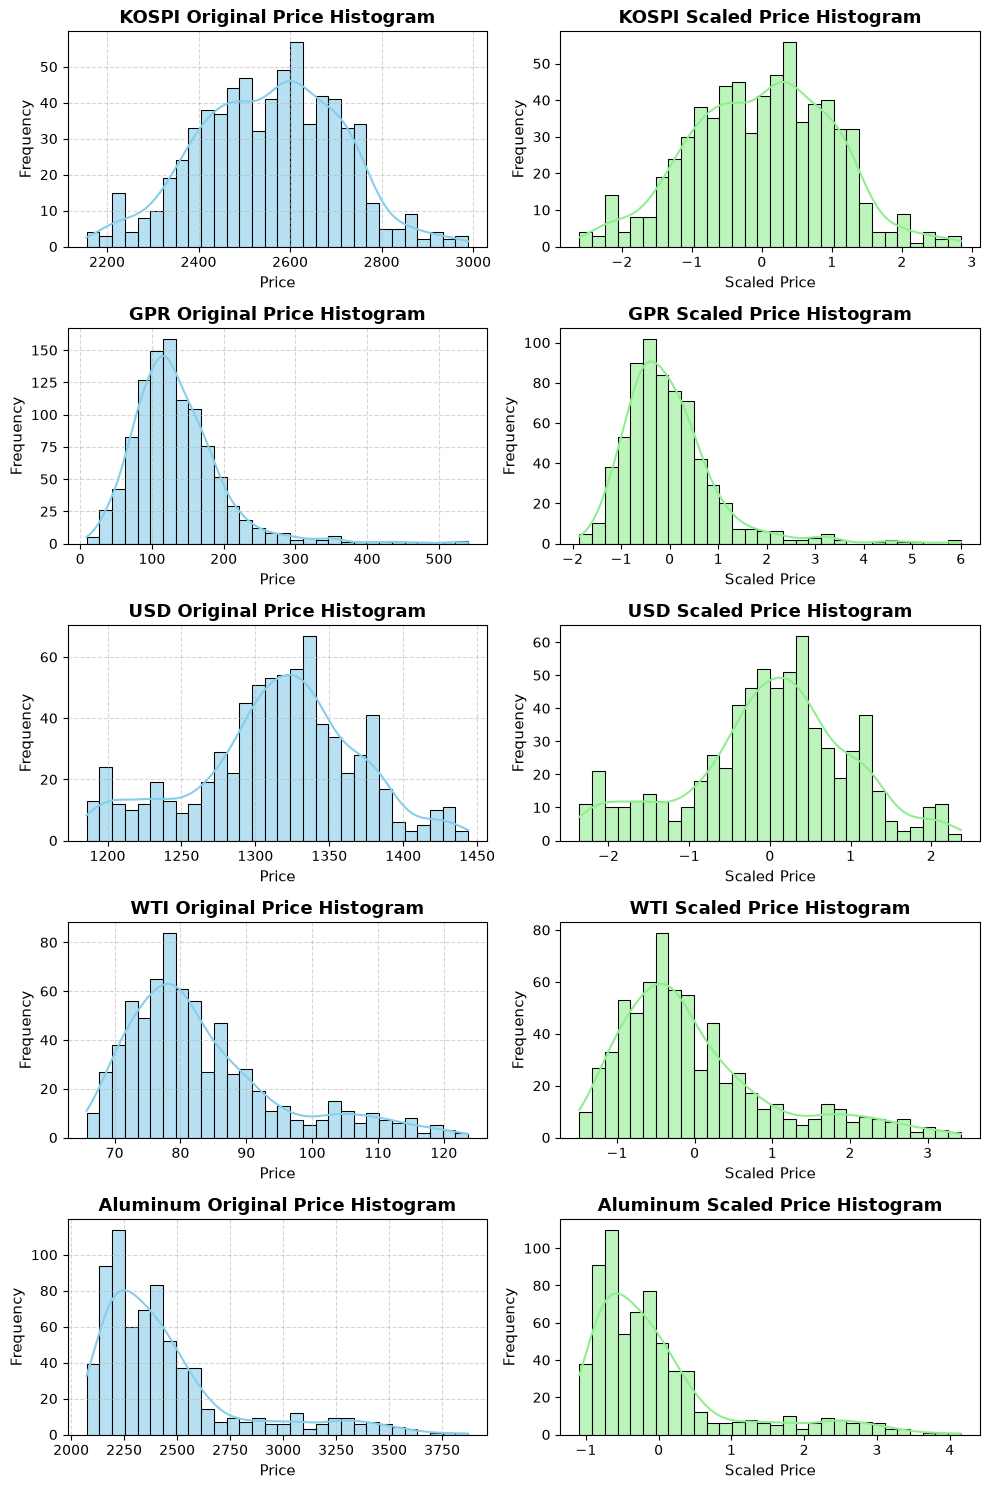

In [15]:
# 원래 변수 vs 표준화된 변수 히스토그램 비교
# 1. 시각화할 데이터셋 정보 정의 (변수명, 컬럼명, 타이틀, 원래 가격 단위 라벨)
comparison_dist_configs = [
    (KOSPI, "Close", "KOSPI", "Price"),
    (GPR, "GPRD", "GPR", "Price"),
    (usd_krw, "Close", "USD", "Price"),
    (wti_crude, "Close", "WTI", "Price"),
    (aluminum, "Close", "Aluminum", "Price")
]

# 2. 서브플롯 생성
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 15))

# 3. 개별 플롯 생성
for (ax_price, ax_returns), (df, col, label, price_unit) in zip(axes, comparison_dist_configs):
    # 데이터 추출 및 표준화된 데이터 선택
    price_original = df[col]
    price_scaled = scaled_data[label]

    # [왼쪽 열] 원래 변수 히스토그램 및 KDE(smooth cureve of data)
    sns.histplot(price_original, kde=True, color='skyblue', bins=30, ax=ax_price, alpha=0.6)
    ax_price.set_title(f'{label} Original Price Histogram', fontsize=13, fontweight='bold')
    ax_price.set_xlabel('Price', fontsize=11)
    ax_price.set_ylabel('Frequency', fontsize=11)
    ax_price.grid(True, linestyle="--", alpha=0.5)

    # [오른쪽 열] 표준화된 변수 히스토그램 및 KDE
    sns.histplot(price_scaled, kde=True, color='lightgreen', bins=30, ax=ax_returns, alpha=0.6)
    ax_returns.set_title(f'{label} Scaled Price Histogram', fontsize=13, fontweight='bold')
    ax_returns.set_xlabel('Scaled Price', fontsize=11)
    ax_returns.set_ylabel('Frequency', fontsize=11)
    ax_price.grid(True, linestyle="--", alpha=0.5)

# 4. 플롯 간 간격 조절 및 출력
plt.tight_layout()
plt.show()

- 원본 데이터의 분포가 유지됨.

#### 3. KOSPI 지수 vs. 나머지 변수 시차 조정

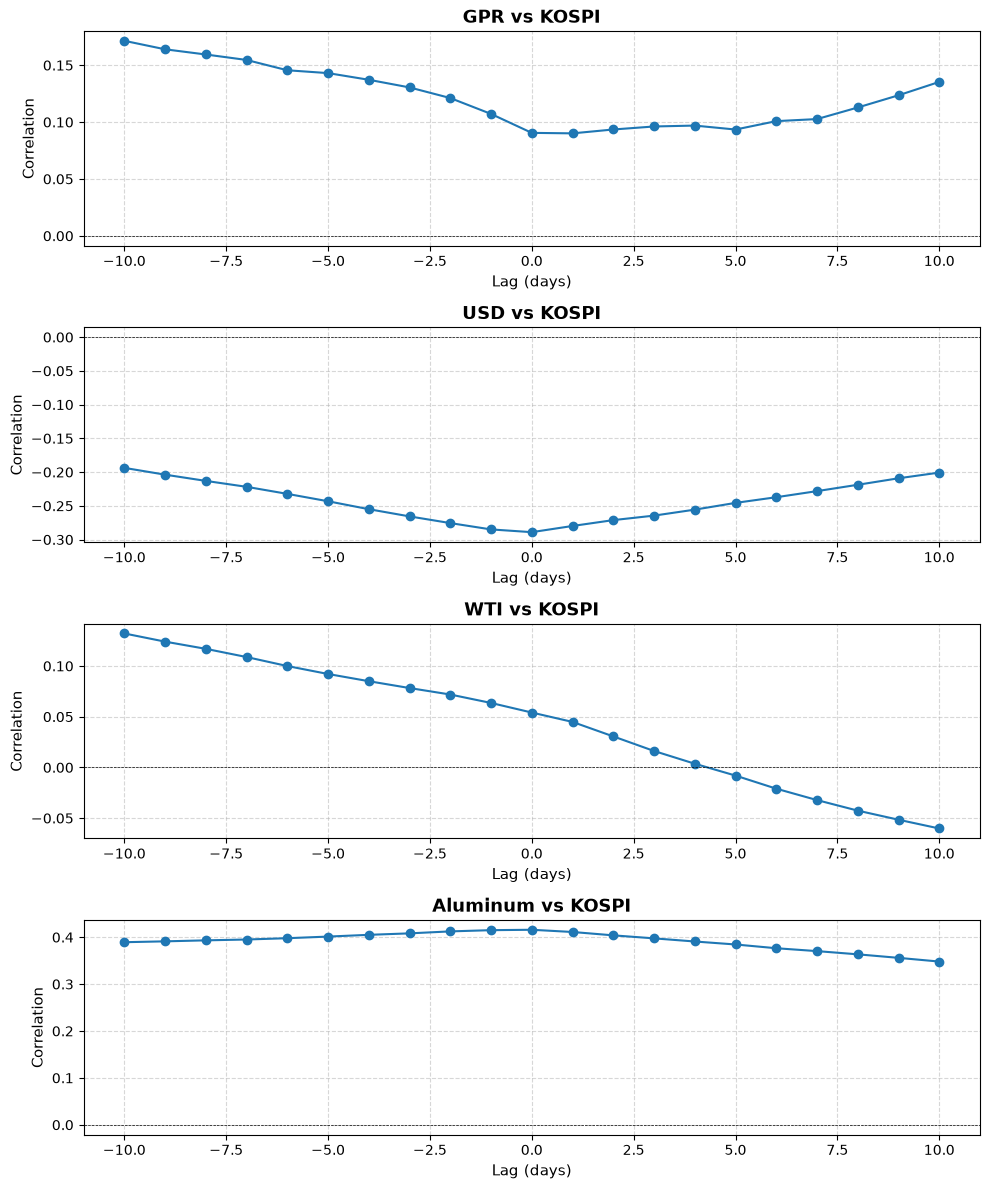

교차 상관 분석 결과 :


,GPR,USD,WTI,Aluminum
-10,0.171453,-0.193736,0.132097,0.389337
-9,0.163988,-0.203786,0.124026,0.391182
-8,0.159422,-0.213029,0.116926,0.393299
-7,0.154613,-0.221800,0.108842,0.395104
-6,0.145559,-0.232251,0.099968,0.397878
-5,0.143054,-0.243199,0.092121,0.401336
-4,0.137196,-0.254948,0.085021,0.405073
-3,0.130472,-0.265631,0.078272,0.408203
-2,0.121133,-0.275550,0.071883,0.412406
-1,0.107175,-0.284932,0.063571,0.415000


In [16]:
# 각 변수의 KOSPI에 대한 시차 관계 검정
# 1. 시각화할 데이터셋 및 분석 정보 정의 (변수, 이름, 최대 시차)
indep_vars = [scaled_data['GPR'], scaled_data['USD'], scaled_data['WTI'], scaled_data['Aluminum']]
indep_vars_names = ['GPR', 'USD', 'WTI', 'Aluminum']
dep_var = scaled_data['KOSPI']
max_lag = 10

# 2. 서브플롯 생성
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(10, 12))

# 3. 함수 정의 : 교차상관 계산
def cross_correlation_analysis(series1, series2, max_lag):
    lags = range(-max_lag, max_lag + 1)
    correlations = [series1.corr(series2.shift(lag)) for lag in lags]
    return lags, correlations

# 교차 상관 결과 저장할 데이터 프레임 생성
results = pd.DataFrame(index=range(-max_lag, max_lag + 1), columns=indep_vars_names)

# 4. 개별 플롯 생성 및 교차 상관 분석 진행
for ax, var, name in zip(axs, indep_vars, indep_vars_names):
    # 교차상관 계산 및 결과 저장
    lags, correlations = cross_correlation_analysis(dep_var, var, max_lag)
    results[name] = correlations

    # 결과 시각화
    ax.plot(lags, correlations, marker='o')
    ax.set_title(f'{name} vs KOSPI', fontsize=13, fontweight='bold')
    ax.set_xlabel('Lag (days)', fontsize=11)
    ax.set_ylabel('Correlation', fontsize=11)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.grid(True, linestyle="--", alpha=0.5)

# 5. 플롯 간 간격 조절 및 출력
plt.tight_layout()
plt.show()

# 표 출력
print("교차 상관 분석 결과 :")
results

- GPR 지수는 강한 상관관계가 나타나는 시차가 존재하지 않음 → 그대로 유지
- 원달러환율은 0시차에서 -0.289의 음의 상관관계 존재함 → 동행, 그대로 유지
- WTI 원유 선물은 강한 상관관계가 나타나는 시차가 존재하지 않음 → 그대로 유지
- 알루미늄 선물 가격은 0시차에서 0.416으로 양의 상관관계 존재함 → 동행, 그대로 유지

In [17]:
# 다변량 시차 관계 검정 : VAR 모형 적합 및 계수 추정
# 1. 데이터 차분 및 정상성 확인 (ADF 검정)
diff_data = scaled_data[['KOSPI', 'GPR', 'USD', 'WTI', 'Aluminum']].diff().dropna()

print("--- ADF 단위근 검정 결과 (p-value) ---")
for col in diff_data.columns:
    p_val = adfuller(diff_data[col])[1]
    print(f"{col}: {p_val:.4f}")
print("---------------------------------------")

# 2. VAR 모형 적합 및 최대 지연 시 설정
var_model = VAR(diff_data)
results = var_model.fit(maxlags=4)

# 3. KOSPI 방정식의 계수 및 통계적 유의성 추출
kospi_coefficients = results.params['KOSPI']
kospi_pvalues = results.pvalues['KOSPI']

# 4. 분석 결과 요약 및 표 출력
kospi_summary = pd.DataFrame({
    'Coefficient': kospi_coefficients,
    'P-Value': kospi_pvalues
})

print("\n교차 상관 분석 결과 (KOSPI 요약) :")
kospi_summary

--- ADF 단위근 검정 결과 (p-value) ---
KOSPI: 0.0000
GPR: 0.0000
USD: 0.0000
WTI: 0.0000
Aluminum: 0.0000
---------------------------------------

교차 상관 분석 결과 (KOSPI 요약) :


c:\Python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,Coefficient,P-Value
const,-0.002911,0.695280
L1.KOSPI,-0.020585,0.618614
L1.GPR,-0.006689,0.554680
L1.USD,0.003239,0.950540
L1.WTI,0.098149,0.014371
L1.Aluminum,0.109670,0.092961
L2.KOSPI,-0.036857,0.382220
L2.GPR,-0.002640,0.835143
L2.USD,0.048829,0.354844
L2.WTI,0.016484,0.683073


- 각 변수들은 1차 차분한 경우 정상성을 만족함.
- L1.WTI와 KOSPI 사이 VAR 모형의 계수는 0.098149, p-value는 약 0.01임
    - WTI 전일 변동과 당일 KOSPI 지수 변동 사이에는 통계적으로 유의미한 양의 시차 관계가 존재함.
    - WTI 원유 가격의 상승세가 평소보다 1표준편차만큼 강해지면, 다음 날 KOSPI 지수의 상승 모멘텀이 약 0.098 표준편차만큼 강화됨.(즉, 전날 유가가 강세를 보였다면 다음날 KOSPI 지수 또한 상승 압력을 받을 가능성이 존재함.)
    - WTI 원유 선물 데이터가 1시점 지연되도록 시차 조정해야함.

In [18]:
# WTI 원유 선물 1시차 지연 조정
model_data=scaled_data.copy()
model_data['L1.WTI']=scaled_data['WTI'].shift(1)
model_data=model_data.dropna()
model_data=model_data[['KOSPI','GPR','USD','L1.WTI','Aluminum']]
model_data.rename(columns={'L1.WTI':'WTI'}, inplace=True)
display(model_data)

,KOSPI,GPR,USD,WTI,Aluminum
Date,,,,,
2022-01-05,2.613414,-0.890192,-2.165748,-0.530992,1.249422
2022-01-06,2.394833,-1.317360,-2.115367,-0.458089,1.290216
2022-01-07,2.619427,-0.527433,-1.995734,-0.321608,1.274190
2022-01-10,2.435293,-0.349145,-2.158786,-0.369079,1.315713
2022-01-11,2.439607,0.601551,-2.136619,-0.425876,1.467963
...,...,...,...,...,...
2024-10-24,0.175683,-0.113241,1.147323,-1.058266,0.437175
2024-10-25,0.190325,0.881030,1.128636,-1.107433,0.529691
2024-10-28,0.380929,0.025571,1.336391,-0.972647,0.417506


# 6. 모델링

#### 1.  반응변수 vs. 설명변수 상관분석

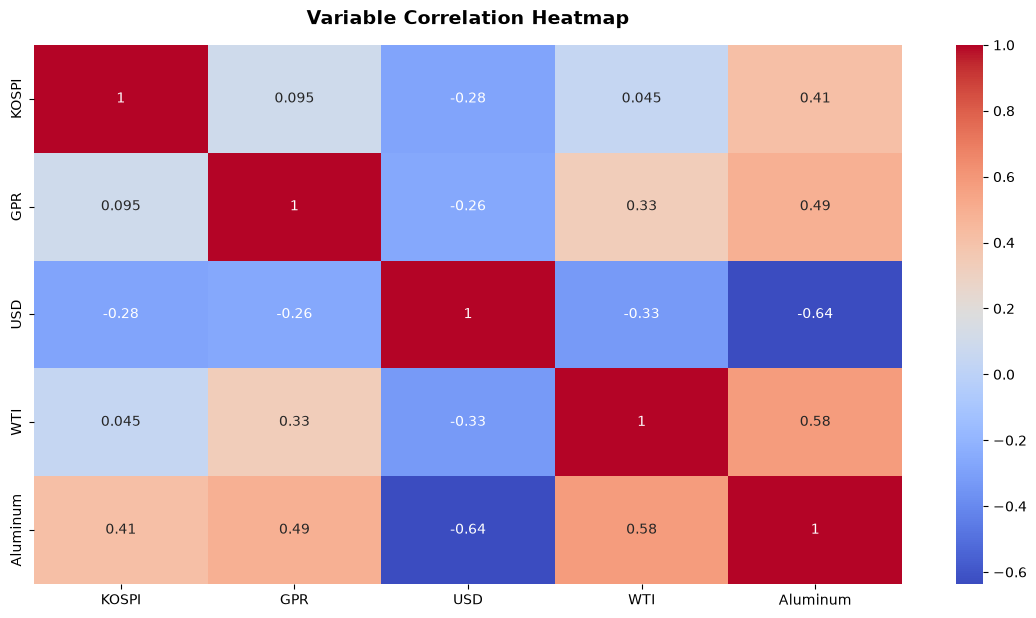

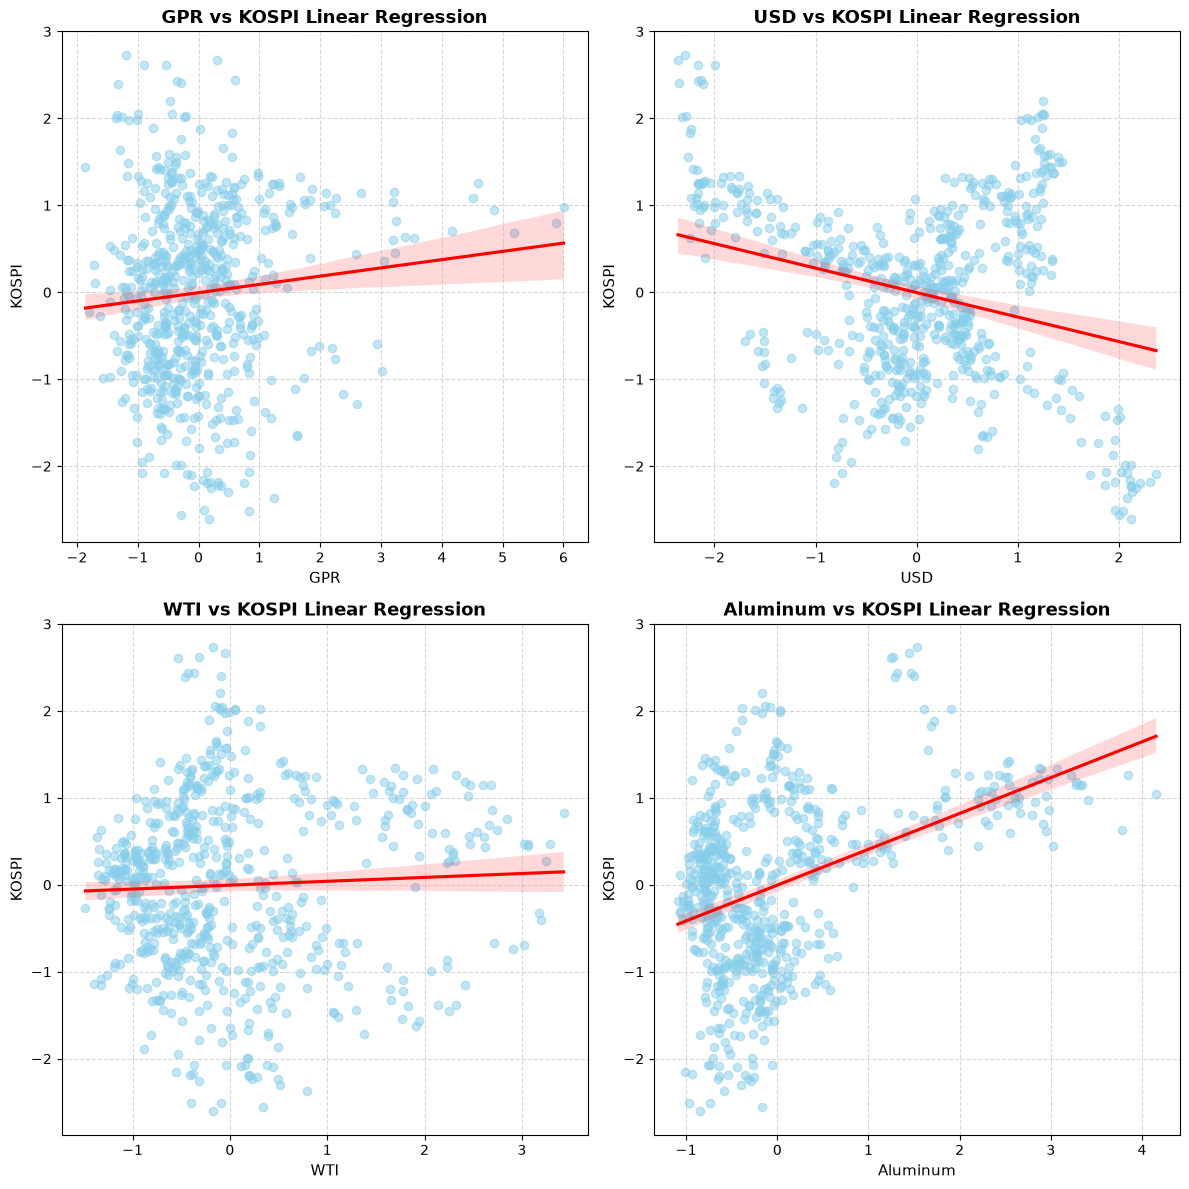

In [19]:
## 변수들간 상관계수 및 산점도-회귀직선 비교 분석
# 1. 전체 상관계수 히트맵 출력
plt.figure(figsize=(14, 7))
sns.heatmap(model_data.corr(), annot=True, cmap='coolwarm')
plt.title('Variable Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.show()

# 2. 2x2 서브플롯 생성
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
indep_vars = ['GPR', 'USD', 'WTI', 'Aluminum']

# 3. 개별 설명변수 vs KOSPI 산점도 및 회귀직선 출력
for ax, var in zip(axes.flatten(), indep_vars):
    sns.regplot(x=var, y='KOSPI', data=model_data, ax=ax,
                scatter_kws={'alpha': 0.5, 'color': 'skyblue'}, line_kws={'color': 'red'})
    
    ax.set_title(f'{var} vs KOSPI Linear Regression', fontsize=13, fontweight='bold')
    ax.set_xlabel(var, fontsize=11)
    ax.set_ylabel('KOSPI', fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)

# 4. 플롯 간 간격 조절 및 출력
plt.tight_layout()
plt.show()

- 상관분석 결과
    - *KOSPI 지수 vs.*
        - GPI 지수: 상관계수 0.095, 전체 분석 기간에서 상관성이 매우 작음
        - 원달러환율: 상관계수 -0.28, 서로 반대 방향으로 움직임
        - WTI 원유 선물: 상관계수 0.045, 전체 분석 기간에서 상관성이 매우 작음
        - 알루미늄 선물: 상관계수 0.41, 서로 같은 방향으로 움직임

- 산점도 + 적합된 회귀석 분석 겨로가
    - *KOSPI 지수 vs.*
        - GPI 지수: 무작위적(random)
        - 원달러환율: 선형관계 존재, 추가로 곡선적 관계가 존재함
        - WTI 원유 선물: 무작위적(random)
        - 알루미늄 선물: 선형관계 존재

#### 2. 단순선형회귀분석 및 잔차분석

- 단순선형회귀 :
$y_{i} = \beta_{1} + \beta_{2}x_{i} + e_{i} ,  e_{i}$ ~ $i.i.d. N(0, \sigma^{2})$  for $i = 1, ..., n$

In [20]:
# 설명변수별 단순선형회귀 모형 적합
# 1. 상수항 추가 및 학습/테스트 데이터 분리
model_data['const'] = 1

train_size = int(len(model_data) * 0.8)
train_data = model_data[:train_size]
test_data = model_data[train_size:]

print('학습 데이터 : ')
display(train_data.head())
print('테스트 데이터 : ')
display(test_data.head())

# 2. 개별 모형의 설명변수 정의
xnames_1 = ['const', 'GPR']
xnames_2 = ['const', 'USD']
xnames_3 = ['const', 'WTI']
xnames_4 = ['const', 'Aluminum']

# 3. 단순선형회귀 모형 추정 (OLS)
reg1 = sm.OLS(train_data.KOSPI, train_data[xnames_1]).fit()
reg2 = sm.OLS(train_data.KOSPI, train_data[xnames_2]).fit()
reg3 = sm.OLS(train_data.KOSPI, train_data[xnames_3]).fit()
reg4 = sm.OLS(train_data.KOSPI, train_data[xnames_4]).fit()

results = [reg1, reg2, reg3, reg4]
model_names = ['GPR', 'USD', 'WTI', 'Aluminum']

# 4. 회귀계수 및 유의성 추출
intercepts = [model.params['const'] for model in results]
intercept_pvalues = [model.pvalues['const'] for model in results]
slopes = [model.params[model_names[i]] if model_names[i] in model.params else float('nan') for i, model in enumerate(results)]
slope_pvalues = [model.pvalues[model_names[i]] if model_names[i] in model.pvalues else float('nan') for i, model in enumerate(results)]

# 5. 모형 적합도 및 정당성 평가 지표 추출
r_squared = [model.rsquared for model in results]
adj_r_squared = [model.rsquared_adj for model in results]
aic_values = [model.aic for model in results]
bic_values = [model.bic for model in results]

# 6. 통계적 유의성 표시 함수 정의
def significance_stars(pvalue):
    if pvalue < 0.01:
        return '***'
    elif pvalue < 0.05:
        return '**'
    elif pvalue < 0.1:
        return '*'
    else:
        return ''

# 7. 분석 결과 요약 데이터프레임 생성 및 출력
data = {'Fitted': ['Intercept', 'Slope', 'R-squared', 'Adjusted R-squared', 'AIC', 'BIC']}

for i, name in enumerate(model_names):
    intercept_star = significance_stars(intercept_pvalues[i])
    slope_star = significance_stars(slope_pvalues[i])
    data[name] = [
        f"{intercepts[i]:.5f} {intercept_star} ({intercept_pvalues[i]:.5f})",
        f"{slopes[i]:.5f} {slope_star} ({slope_pvalues[i]:.5f})",
        f"{r_squared[i]:.5f}",
        f"{adj_r_squared[i]:.5f}",
        f"{aic_values[i]:.2f}",
        f"{bic_values[i]:.2f}"
    ]

result_df = pd.DataFrame(data)
results_table = result_df.set_index('Fitted')

print('모형 적합 결과 : ')
results_table

학습 데이터 : 


,KOSPI,GPR,USD,WTI,Aluminum,const
Date,,,,,,
2022-01-05,2.613414,-0.890192,-2.165748,-0.530992,1.249422,1
2022-01-06,2.394833,-1.317360,-2.115367,-0.458089,1.290216,1
2022-01-07,2.619427,-0.527433,-1.995734,-0.321608,1.274190,1
2022-01-10,2.435293,-0.349145,-2.158786,-0.369079,1.315713,1
2022-01-11,2.439607,0.601551,-2.136619,-0.425876,1.467963,1


테스트 데이터 : 


,KOSPI,GPR,USD,WTI,Aluminum,const
Date,,,,,,
2024-04-04,1.227867,0.150812,0.551908,0.184474,-0.176199,1
2024-04-05,1.046217,-0.154802,0.671358,0.282807,-0.151430,1
2024-04-08,1.068702,-0.408534,0.651389,0.309935,-0.121563,1
2024-04-09,0.987061,0.324762,0.723754,0.269244,-0.116464,1
2024-04-11,0.998827,-0.456733,0.898532,0.167520,-0.141232,1


모형 적합 결과 : 


,GPR,USD,WTI,Aluminum
Fitted,,,,
Intercept,-0.22744 *** (0.00000),-0.35860 *** (0.00000),-0.23730 *** (0.00000),-0.22158 *** (0.00000)
Slope,0.18215 *** (0.00000),-0.63590 *** (0.00000),0.13955 *** (0.00039),0.43793 *** (0.00000)
R-squared,0.04060,0.42082,0.02349,0.25065
Adjusted R-squared,0.03879,0.41972,0.02165,0.24923
AIC,1450.29,1181.80,1459.69,1318.83
BIC,1458.84,1190.35,1468.25,1327.39


- 단순선형회귀모형 적합 결과
    - *KOSPI 지수에 대한 영향력*
        - GPR 지수: 회귀계수 0.18215, p-value<0.05로 통계적으로 유의
        - GPR 지수가 1표준편차 증가할 때, KOSPI 지수는 0.18215표준편차 증가
        - 원달러환율, WTI 원유 선물, 알루미늄 선물의 회귀계수도 모두 통계적으로 유의
        - KOSPI 지수에 대한 영향력은 원달러환율, 알루미늄 선물, GPR 지수, WTI 원유 선물 순으로 큼

    - *KOSPI 지수 변동 설명력*
        - 원달러환율은 단독 요인만으로 KOSPI 지수 변동의 약 42%를 설명함
        - 알루미늄 선물은 단독 요인으로 KOSPI 지수 변동의 약 25%를 설명함

In [21]:
# 단순선형회귀 모형별 예측 성능 평가

# 1. 테스트 데이터 기반의 KOSPI 예측값 생성
predictions = [model.predict(test_data[xnames]) for model, xnames in zip(results, [xnames_1, xnames_2, xnames_3, xnames_4])]

# 2. 모형별 예측 평가 지표(MSE, MAE) 계산
mse_values = [mean_squared_error(test_data.KOSPI, pred) for pred in predictions]
mae_values = [mean_absolute_error(test_data.KOSPI, pred) for pred in predictions]

# 3. 예측 성능 평가 요약 데이터프레임 생성
data_test = {'Performance': ['MSE', 'MAE']}

for i, name in enumerate(model_names):
    data_test[name] = [
        f"{mse_values[i]:.5f}",
        f"{mae_values[i]:.5f}"
    ]

performance_table = pd.DataFrame(data_test)
performance_table = performance_table.set_index('Performance')

# 4. 최종 예측 성능 결과 출력
print("Test set 예측 성능:")
display(performance_table)

Test set 예측 성능:


,GPR,USD,WTI,Aluminum
Performance,,,,
MSE,1.63329,3.64945,1.63472,1.56037
MAE,1.11998,1.77150,1.16261,1.08516


- MSE, MAE 모두 Aluminum에서 가장 낮음
    - 알루미늄 선물이 단독 요인으로서 KOSPI 지수에 대한 예측력이 가장 높음
- 원달러환율은 KOSPI 지수와 선형성을 가정하고 예측을 수행했을 때 성능이 좋지 않음

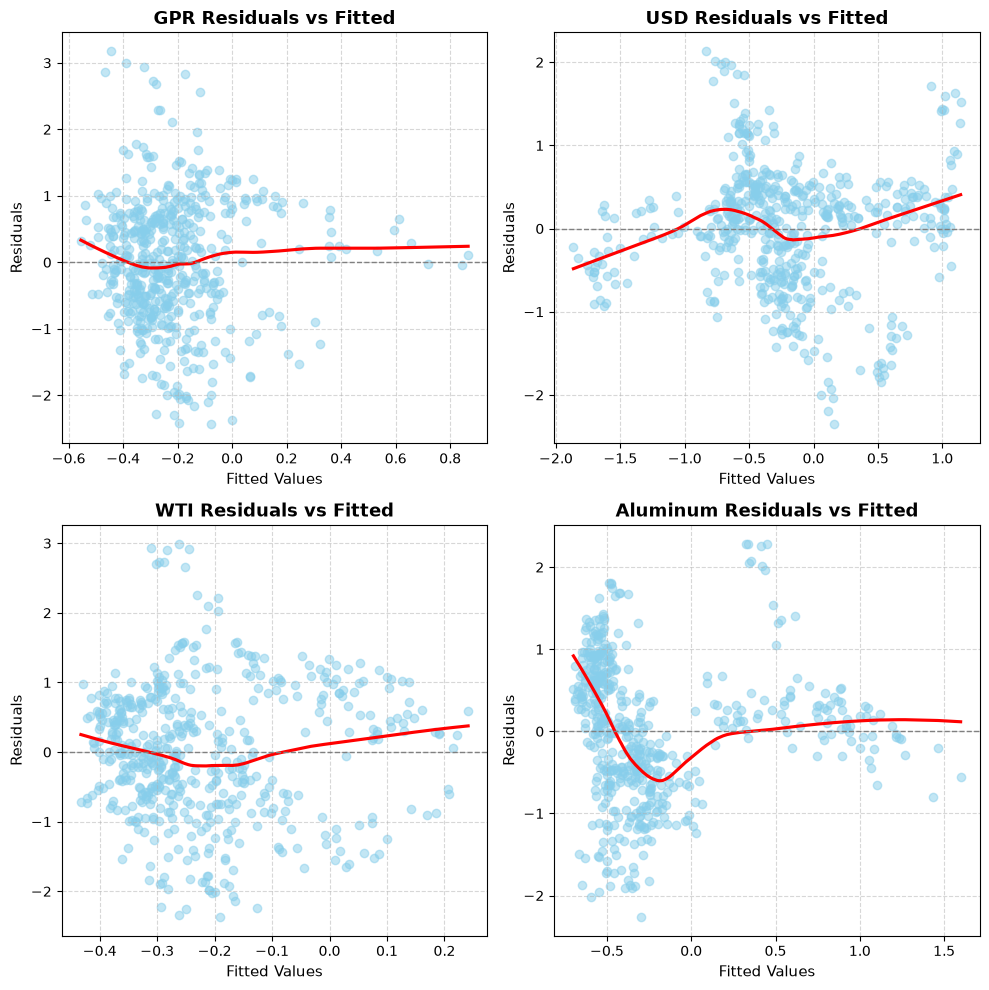

In [22]:
# 잔차분석: 단순선형회귀 모형별 예측치 vs. 잔차 산점도 및 LOWESS 곡선 시각화

# 1. 2x2 서브플롯 생성
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

# 2. 개별 모형의 예측값 대비 잔차 플롯 생성
for ax, model, name in zip(axes.flatten(), results, model_names):
    # 모형별 예측치(Fitted) 및 잔차(Residuals) 추출
    fitted_values = model.fittedvalues
    residuals = model.resid
    
    # 산점도 및 LOWESS 곡선 시각화
    sns.regplot(x=fitted_values, y=residuals, lowess=True, ax=ax,
                scatter_kws={'alpha': 0.5, 'color': 'skyblue'}, line_kws={'color': 'red'})
    
    # 기준선(y=0) 추가 및 라벨 설정
    ax.axhline(y=0, color='grey', linestyle='--', linewidth=1)
    ax.set_title(f'{name} Residuals vs Fitted', fontsize=13, fontweight='bold')
    ax.set_xlabel('Fitted Values', fontsize=11)
    ax.set_ylabel('Residuals', fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)

# 3. 플롯 간 간격 조절 및 출력
plt.tight_layout()
plt.show()

- 잔차분석 결과:
    - GPR 지수 WTI 원유 선물: 잔차가 무작위적으로 분포하고, LOWESS 평활곡선이 거의 수평을 이루어 KOSPI 지수와 선형성 가정만으로 충분히 설명됨
    - 원달러환율: 잔차가 특정 예측값을 기준으로 군집되어 있으며, LOWESS 평활곡선이 3차함수의 양상을 보임
    - 알루미늄 선물: 잔차가 특정 예측값을 기준으로 군집되어 있으며, LOWESS 평활곡선이 수평에서 벗어나 비선형적인 양상 보임

- 추가분석 방향성:
    - 원달러환율: 2차항, 3차항 추가
    - 알루미늄 선물: Signed Log Transform 수행

#### 3. 다중선형회귀분석


- 다중선형회귀모형 : 
$y_{i} = \beta_{1} + \beta_{2}x_{i1} + \beta_{3}x_{i2} + \beta_{4}x_{i1}x_{i2} + e_{i}, e_{i} \sim i.i.d.\ N(0, \sigma^{2}) \text{ for } i = 1, \ldots, n$

In [23]:
# 데이터 셋 리셋
model_data=scaled_data.copy()
model_data['L1.WTI']=scaled_data['WTI'].shift(1)
model_data=model_data.dropna()
model_data=model_data[['KOSPI','GPR','USD','L1.WTI','Aluminum']]
model_data.rename(columns={'L1.WTI':'WTI'}, inplace=True)

In [ ]:
# 교호작용항 검토
# 1. 설명변수들 간의 상관계수 행렬
X = model_data.iloc[:, 1:5]
print('설명변수 간의 상관계수 행렬:')
display(X.corr())

# 2. 교호작용항 추가 (GPR vs. .otherwise)
model_data['GPR_USD']=model_data['GPR']*model_data['USD']
model_data['GPR_WTI']=model_data['GPR']*model_data['WTI']
model_data['GPR_Aluminum']=model_data['GPR']*model_data['Aluminum']
print('교호작용항 추가된 model data:')
display(model_data.head())

설명변수 간의 상관계수 행렬:


,GPR,USD,WTI,Aluminum
GPR,1.000000,-0.259994,0.334877,0.494317
USD,-0.259994,1.000000,-0.327958,-0.636238
WTI,0.334877,-0.327958,1.000000,0.579675
Aluminum,0.494317,-0.636238,0.579675,1.000000


교호작용 항 추가된 model data:


,KOSPI,GPR,USD,WTI,Aluminum,GPR_USD,GPR_WTI,GPR_Aluminum
Date,,,,,,,,
2022-01-05,2.613414,-0.890192,-2.165748,-0.530992,1.249422,1.927932,0.472685,-1.112225
2022-01-06,2.394833,-1.317360,-2.115367,-0.458089,1.290216,2.786700,0.603468,-1.699679
2022-01-07,2.619427,-0.527433,-1.995734,-0.321608,1.274190,1.052616,0.169627,-0.672050
2022-01-10,2.435293,-0.349145,-2.158786,-0.369079,1.315713,0.753729,0.128862,-0.459374
2022-01-11,2.439607,0.601551,-2.136619,-0.425876,1.467963,-1.285286,-0.256186,0.883055


In [25]:
# 설명변수간 다중공선성 여부 검토
# 1. 설명변수들 간의 상관계수 행렬
X = model_data.iloc[:, 1:8]
print('설명변수 간의 상관계수 행렬:')
display(X.corr())

# 2. 각 설명변수에 대한 VIF 값
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print('각 설명변수에 대한 VIF 값:')
display(vif_data)

설명변수 간의 상관계수 행렬:


,GPR,USD,WTI,Aluminum,GPR_USD,GPR_WTI,GPR_Aluminum
GPR,1.000000,-0.259994,0.334877,0.494317,-0.559112,0.543238,0.617229
USD,-0.259994,1.000000,-0.327958,-0.636238,0.327289,-0.350461,-0.399789
WTI,0.334877,-0.327958,1.000000,0.579675,-0.312790,0.291954,0.342651
Aluminum,0.494317,-0.636238,0.579675,1.000000,-0.583497,0.560297,0.618621
GPR_USD,-0.559112,0.327289,-0.312790,-0.583497,1.000000,-0.687523,-0.914584
GPR_WTI,0.543238,-0.350461,0.291954,0.560297,-0.687523,1.000000,0.824415
GPR_Aluminum,0.617229,-0.399789,0.342651,0.618621,-0.914584,0.824415,1.000000


각 설명변수에 대한 VIF 값:


,Variable,VIF
0,GPR,1.665931
1,USD,1.758390
2,WTI,1.532525
3,Aluminum,3.065003
4,GPR_USD,7.194825
5,GPR_WTI,3.696181
6,GPR_Aluminum,12.380444


- GPR 지수와 알루미늄 선물 사이 교호작용항은 VIF 지수가 10을 초과하여 다중공선성 문제를 발생시킬 수 있음.
- 그러나, 연구의 목적대로 '지정학적 위험이 KOSPI 지수에 미치는 영향을 세부적으로 분석'하기 위해, GPR 지수와 나머지 변수간의 교호작용항을 모두 포함시킴.

In [26]:
# 다중선형회귀 모형 적합
# 1. 상수항 추가 및 학습/테스트 데이터 분리
model_data['const'] = 1

train_size = int(len(model_data) * 0.8)
train_data = model_data[:train_size]
test_data = model_data[train_size:]

print('학습 데이터 : ')
display(train_data.head())
print('테스트 데이터 : ')
display(test_data.head())

# 2. 다중선형회귀 모형별 설명변수 및 종속변수 정의
y = train_data['KOSPI']
xnames0 = ['const', 'GPR', 'USD', 'WTI', 'Aluminum']                             # Full 모형
xnames1 = ['const', 'USD', 'GPR_USD', 'WTI', 'GPR_WTI', 'Aluminum', 'GPR_Aluminum'] # 교호작용항 포함 모형

# 3. 다중선형회귀 모형 추정 (OLS)
reg01 = sm.OLS(y, train_data[xnames0]).fit()
reg02 = sm.OLS(y, train_data[xnames1]).fit()

models = {'Full_X': reg01, 'Full_Interaction': reg02}
model_names = list(models.keys())
variables = ['const', 'GPR', 'USD', 'WTI', 'Aluminum', 'GPR_USD', 'GPR_WTI', 'GPR_Aluminum']

# 4. 통계적 유의성 표시 함수 차용
# def significance_stars(pvalue)

# 5. 분석 결과 요약 데이터프레임 구성
data = {'Fitted': variables + ['R-squared', 'Adjusted R-squared', 'AIC', 'BIC']}

# 6. 모형별 추정 결과 및 정당성 평가 지표 추출
for name, model in models.items():
    params = model.params
    pvalues = model.pvalues
    intercept_star = significance_stars(pvalues['const']) if 'const' in pvalues else ''

    # 변수별 회귀계수 및 p-value 저장
    row = [f"{params['const']:.5f} {intercept_star} ({pvalues['const']:.5f})" if 'const' in params else '']
    for var in variables[1:]:
        if var in params:
            star = significance_stars(pvalues[var])
            row.append(f"{params[var]:.5f} {star} ({pvalues[var]:.5f})")
        else:
            row.append('')

    # 모형 적합도 및 정보 기준 지표 추가
    row += [f"{model.rsquared:.5f}", f"{model.rsquared_adj:.5f}", f"{model.aic:.5f}", f"{model.bic:.5f}"]
    data[name] = row

result_df = pd.DataFrame(data)
results_table = result_df.set_index('Fitted')

# 7. 최종 결과 데이터 출력
results_table

학습 데이터 : 


,KOSPI,GPR,USD,WTI,Aluminum,GPR_USD,GPR_WTI,GPR_Aluminum,const
Date,,,,,,,,,
2022-01-05,2.613414,-0.890192,-2.165748,-0.530992,1.249422,1.927932,0.472685,-1.112225,1
2022-01-06,2.394833,-1.317360,-2.115367,-0.458089,1.290216,2.786700,0.603468,-1.699679,1
2022-01-07,2.619427,-0.527433,-1.995734,-0.321608,1.274190,1.052616,0.169627,-0.672050,1
2022-01-10,2.435293,-0.349145,-2.158786,-0.369079,1.315713,0.753729,0.128862,-0.459374,1
2022-01-11,2.439607,0.601551,-2.136619,-0.425876,1.467963,-1.285286,-0.256186,0.883055,1


테스트 데이터 : 


,KOSPI,GPR,USD,WTI,Aluminum,GPR_USD,GPR_WTI,GPR_Aluminum,const
Date,,,,,,,,,
2024-04-04,1.227867,0.150812,0.551908,0.184474,-0.176199,0.083234,0.027821,-0.026573,1
2024-04-05,1.046217,-0.154802,0.671358,0.282807,-0.151430,-0.103927,-0.043779,0.023442,1
2024-04-08,1.068702,-0.408534,0.651389,0.309935,-0.121563,-0.266115,-0.126619,0.049663,1
2024-04-09,0.987061,0.324762,0.723754,0.269244,-0.116464,0.235048,0.087440,-0.037823,1
2024-04-11,0.998827,-0.456733,0.898532,0.167520,-0.141232,-0.410389,-0.076512,0.064505,1


,Full_X,Full_Interaction
Fitted,,
const,-0.33403 *** (0.00000),-0.33324 *** (0.00000)
GPR,0.02069 (0.56137),
USD,-0.56611 *** (0.00000),-0.58250 *** (0.00000)
WTI,-0.08191 ** (0.04291),-0.07241 * (0.07690)
Aluminum,0.10826 * (0.07163),0.07457 (0.25197)
GPR_USD,,-0.16690 ** (0.01596)
GPR_WTI,,0.04990 (0.27490)
GPR_Aluminum,,-0.11601 ** (0.04700)
R-squared,0.42742,0.43367


- 모형① (모든 설명변수만 포함)
    - GPR 지수는 단순선형회귀모형에서와 달리 통계적으로 유의하지 않은 요인이 됨
    - 즉, GPR 지수 단독으로는 KOSPI 지수에 유의미한 영향을 미치지 않으나, 환율•유가•원자재가 등 경제적 요인에 의해 간접적으로 영향을 미침

- 모형② (모든 설명변수와 GPR 지수와의 교호작용항 포함)
    - 알루미늄 선물은 단순선형회귀모형에서와 달리 통계적으로 유의하지 않은 요인이 됨
        - 즉, 알루미늄 선물은 KOSPI 지수에 대한 직접적인 영향력보다, 지정학적 리스크를 초래함으로써 미치는 간접적인 영향력이 큼

    - GPR지수와 WTI 원유 선물 사이 교호작용항은 통계적으로 유의하지 않음
    - GPR지수와 원달러환율, GPR지수와 WTI 원유 선물 사이 교호작용항은 통계적으로 유의함
        - 원달러환율이 1표준편차 증가할 때, KOSPI 지수가 0.56611표준편차 감소하는 것 중, 0.11601표준편차만큼은 GPR 지수의 영향을 받아 일어난 것임

- 모형①, 모형②는 알루미늄 선물의 단순선형회귀모형와 설명력이 비슷한 수준

In [27]:
## 다중회귀모형 별 예측 성능 비교
# 1. 테스트 데이터 기반의 모델 조합별 KOSPI 예측값 생성
predictions = {
    'Full_X': models['Full_X'].predict(test_data[xnames0]),
    'Full_Interaction': models['Full_Interaction'].predict(test_data[xnames1])
}

# 2. 모델별 예측 평가 지표(MSE, MAE) 계산 및 데이터 구성
performance_data = {'Performance': ['MSE', 'MAE']}

for name, prediction in predictions.items():
    mse = mean_squared_error(test_data['KOSPI'], prediction)
    mae = mean_absolute_error(test_data['KOSPI'], prediction)

# 3. 예측 성능 평가 요약 데이터프레임 생성
    performance_data[name] = [
        f"{mse:.5f}",
        f"{mae:.5f}"
    ]

performance_table = pd.DataFrame(performance_data)
performance_table = performance_table.set_index('Performance')

# 4. 최종 예측 성능 결과 출력
print("Test set 예측 성능:")
display(performance_table)

Test set 예측 성능:


,Full_X,Full_Interaction
Performance,,
MSE,3.25689,3.14280
MAE,1.64967,1.63279


- MSE, MAE 모두 교호작용을 포함한 모형에서 더 낮음
- 예측성능이 전반적으로 단순선형회귀 모형보다 좋지 않음. (*Bias-Variance trade off*)

#### 4. 추가분석

- 잔차분석 결과 반영
    - USD 는 2차와 3차 항 추가
    - Aluminum은 로그 변환

In [28]:
# 데이터 셋 리셋하기
model_data=scaled_data.copy()
model_data['L1.WTI']=scaled_data['WTI'].shift(1)
model_data=model_data.dropna()
model_data=model_data[['KOSPI','GPR','USD','L1.WTI','Aluminum']]
model_data.rename(columns={'L1.WTI':'WTI'}, inplace=True)

# 교호작용항 추가
model_data['USD_2']=model_data['USD']*model_data['USD']
model_data['USD_3']=model_data['USD']*model_data['USD']*model_data['USD']

# Aluminum 로그변환
model_data['Aluminum']= np.sign(model_data['Aluminum']) * np.log(np.abs(model_data['Aluminum']) + 1)
model_data.head()

,KOSPI,GPR,USD,WTI,Aluminum,USD_2,USD_3
Date,,,,,,,
2022-01-05,2.613414,-0.890192,-2.165748,-0.530992,0.810673,4.690466,-10.158368
2022-01-06,2.394833,-1.317360,-2.115367,-0.458089,0.828646,4.474778,-9.465797
2022-01-07,2.619427,-0.527433,-1.995734,-0.321608,0.821624,3.982954,-7.948916
2022-01-10,2.435293,-0.349145,-2.158786,-0.369079,0.839717,4.660359,-10.060719
2022-01-11,2.439607,0.601551,-2.136619,-0.425876,0.903393,4.565142,-9.753972


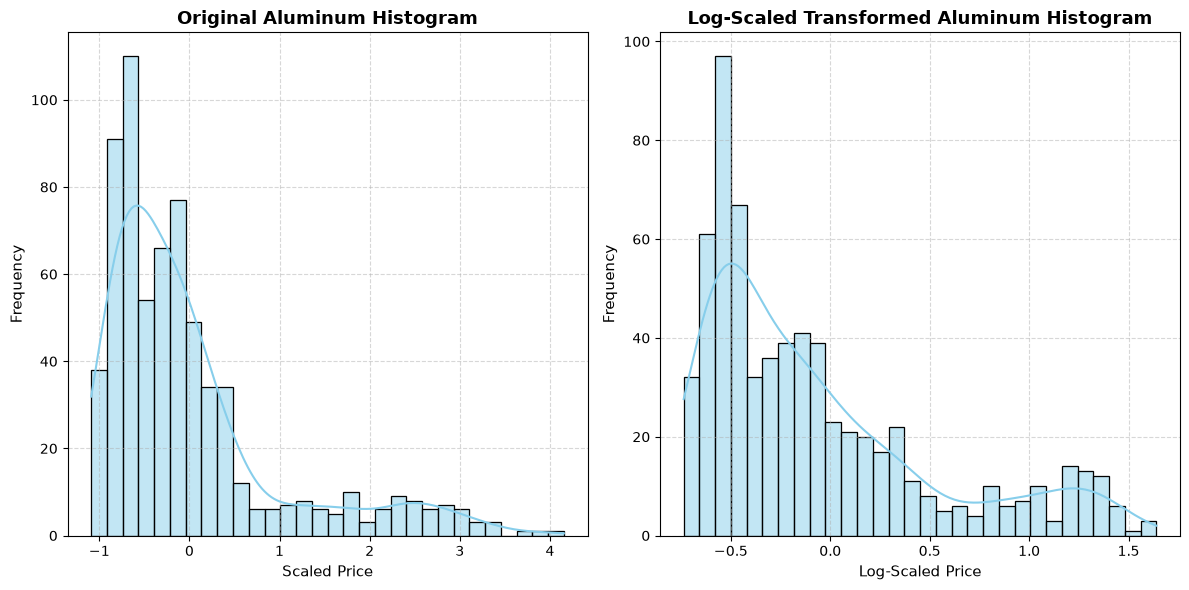

In [29]:
# Aluminum 변수의 로그-스케일 변환 전후 히스토그램 비교

# 1. 서브플롯 생성
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# 2. [왼쪽 열] 원본 데이터 히스토그램 및 KDE
sns.histplot(scaled_data['Aluminum'], kde=True, color='skyblue', bins=30, ax=axes[0])
axes[0].set_title('Original Aluminum Histogram', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Scaled Price', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.5)

# 3. [오른쪽 열] 로그 변환 후 데이터 히스토그램 및 KDE
sns.histplot(model_data['Aluminum'], kde=True, color='skyblue', bins=30, ax=axes[1])
axes[1].set_title('Log-Scaled Transformed Aluminum Histogram', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log-Scaled Price', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.5)

# 4. 플롯 간 간격 조절 및 출력
plt.tight_layout()
plt.show()

In [30]:
# 설명변수간 다중공선성 여부 검토
# 1. 설명변수들 간의 상관계수 행렬
X = model_data.iloc[:, 1:7]
print('설명변수 간의 상관계수 행렬:')
display(X.corr())

# 2. 각 설명변수에 대한 VIF 값
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print('각 설명변수에 대한 VIF 값:')
display(vif_data)

설명변수 간의 상관계수 행렬:


,GPR,USD,WTI,Aluminum,USD_2,USD_3
GPR,1.000000,-0.259994,0.334877,0.424768,0.339113,-0.289691
USD,-0.259994,1.000000,-0.327958,-0.610021,-0.228271,0.876461
WTI,0.334877,-0.327958,1.000000,0.569760,0.288632,-0.218896
Aluminum,0.424768,-0.610021,0.569760,1.000000,0.586933,-0.635219
USD_2,0.339113,-0.228271,0.288632,0.586933,1.000000,-0.296495
USD_3,-0.289691,0.876461,-0.218896,-0.635219,-0.296495,1.000000


각 설명변수에 대한 VIF 값:


,Variable,VIF
0,GPR,1.265221
1,USD,4.841140
2,WTI,1.663643
3,Aluminum,2.570820
4,USD_2,1.280952
5,USD_3,5.149664


In [31]:
# 다양한 변수 조합별 회귀 모형 적합
# 1. 상수항 추가 및 학습/테스트 데이터 분리
model_data['const'] = 1

train_size = int(len(model_data) * 0.8)
train_data = model_data[:train_size]
test_data = model_data[train_size:]

print('학습 데이터 : ')
display(train_data.head())
print('테스트 데이터 : ')
display(test_data.head())

# 2. 모형별 설명변수 및 종속변수 정의
y = train_data['KOSPI']

xnames0 = ['const', 'GPR']
xnames1 = ['const', 'USD']
xnames2 = ['const', 'WTI']
xnames3 = ['const', 'Aluminum']
xnames4 = ['const', 'USD', 'USD_2']
xnames5 = ['const', 'USD', 'USD_2', 'USD_3']
xnames6 = ['const', 'GPR', 'USD', 'WTI', 'Aluminum']
xnames7 = ['const', 'GPR', 'USD', 'USD_2', 'USD_3', 'WTI', 'Aluminum']

# 3. 각 모형 추정 (OLS)
reg01 = sm.OLS(y, train_data[xnames0]).fit()
reg02 = sm.OLS(y, train_data[xnames1]).fit()
reg03 = sm.OLS(y, train_data[xnames2]).fit()
reg04 = sm.OLS(y, train_data[xnames3]).fit()
reg05 = sm.OLS(y, train_data[xnames4]).fit()
reg06 = sm.OLS(y, train_data[xnames5]).fit()
reg07 = sm.OLS(y, train_data[xnames6]).fit()
reg08 = sm.OLS(y, train_data[xnames7]).fit()

models = {
    'GPR': reg01, 'USD': reg02, 'WTI': reg03, 'Al': reg04,
    'U+U2': reg05, 'U+U2+U3': reg06,
    'G+U+W+A': reg07, 'Full': reg08
}
model_names = list(models.keys())
variables = ['const', 'GPR', 'USD', 'USD_2', 'USD_3', 'WTI', 'Aluminum']

# 4. 통계적 유의성 표시 함수 차용
# def significance_stars(pvalue)

# 5. 분석 결과 요약 데이터프레임 구성
data = {'Fitted': variables + ['R-squared', 'Adjusted R-squared', 'AIC', 'BIC']}

# 6. 모형별 추정 결과(계수, 유의성) 및 정당성 평가 지표 추출
for name, model in models.items():
    params = model.params
    pvalues = model.pvalues
    intercept_star = significance_stars(pvalues['const']) if 'const' in pvalues else ''

    # 변수별 회귀계수 및 p-value 저장
    row = [f"{params['const']:.5f} {intercept_star} ({pvalues['const']:.5f})" if 'const' in params else '']
    for var in variables[1:]:
        if var in params:
            star = significance_stars(pvalues[var])
            row.append(f"{params[var]:.5f} {star} ({pvalues[var]:.5f})")
        else:
            row.append('')

    # 모형 적합도 및 정보 기준 지표 추가
    row += [f"{model.rsquared:.5f}", f"{model.rsquared_adj:.5f}", f"{model.aic:.5f}", f"{model.bic:.5f}"]
    data[name] = row

result_df = pd.DataFrame(data)
results_table = result_df.set_index('Fitted')

# 7. 최종 결과 데이터 출력
results_table

학습 데이터 : 


,KOSPI,GPR,USD,WTI,Aluminum,USD_2,USD_3,const
Date,,,,,,,,
2022-01-05,2.613414,-0.890192,-2.165748,-0.530992,0.810673,4.690466,-10.158368,1
2022-01-06,2.394833,-1.317360,-2.115367,-0.458089,0.828646,4.474778,-9.465797,1
2022-01-07,2.619427,-0.527433,-1.995734,-0.321608,0.821624,3.982954,-7.948916,1
2022-01-10,2.435293,-0.349145,-2.158786,-0.369079,0.839717,4.660359,-10.060719,1
2022-01-11,2.439607,0.601551,-2.136619,-0.425876,0.903393,4.565142,-9.753972,1


테스트 데이터 : 


,KOSPI,GPR,USD,WTI,Aluminum,USD_2,USD_3,const
Date,,,,,,,,
2024-04-04,1.227867,0.150812,0.551908,0.184474,-0.162288,0.304602,0.168112,1
2024-04-05,1.046217,-0.154802,0.671358,0.282807,-0.141005,0.450721,0.302595,1
2024-04-08,1.068702,-0.408534,0.651389,0.309935,-0.114723,0.424308,0.276389,1
2024-04-09,0.987061,0.324762,0.723754,0.269244,-0.110166,0.523820,0.379117,1
2024-04-11,0.998827,-0.456733,0.898532,0.167520,-0.132108,0.807359,0.725438,1


,GPR,USD,WTI,Al,U+U2,U+U2+U3,G+U+W+A,Full
Fitted,,,,,,,,
const,-0.22744 *** (0.00000),-0.35860 *** (0.00000),-0.23730 *** (0.00000),-0.15440 *** (0.00003),-0.36512 *** (0.00000),-0.32057 *** (0.00000),-0.34772 *** (0.00000),-0.33045 *** (0.00000)
GPR,0.18215 *** (0.00000),,,,,,0.04439 (0.19019),0.00235 (0.94086)
USD,,-0.63590 *** (0.00000),,,-0.63274 *** (0.00000),-0.03389 (0.61832),-0.62057 *** (0.00000),-0.03154 (0.69620)
USD_2,,,,,0.00714 (0.74442),-0.02568 (0.20815),,-0.02485 (0.37579)
USD_3,,,,,,-0.18543 *** (0.00000),,-0.18839 *** (0.00000)
WTI,,,0.13955 *** (0.00039),,,,-0.04839 (0.25218),0.03201 (0.45143)
Aluminum,,,,0.74592 *** (0.00000),,,0.03699 (0.73096),-0.03790 (0.76955)
R-squared,0.04060,0.42082,0.02349,0.23366,0.42093,0.51171,0.42401,0.51238
Adjusted R-squared,0.03879,0.41972,0.02165,0.23221,0.41874,0.50894,0.41964,0.50680


- 추가 모형 적합 결과:
    - *원달러환율의 영향력*
        - 원달러환율 1차항, 2차항, 3차항을 모함시킨 모형 U+U2+U3에서는 3차항만 유의
        - KOSPI 지수의 변동을 약 51% 설명해서 가장 유효한 모형

    - *알루미늄 선물의 비선형성*
        - 알루미늄 선물의 Signed Log Transform항이 포함된 Al, G+U+W+A 모형에서 설명력이 단순선형회귀모형에서와 유사함
        - 로그변환으로 KOSPI 지수에 대해 가지는 비선형성이 충분히 해소되지 않음

In [32]:
# 다항·다중회귀모형별 예측 성능 평가

# 1. 테스트 데이터 기반의 모델 조합별 KOSPI 예측값 생성
predictions = {
    'U+U2': models['U+U2'].predict(test_data[xnames4]), 
    'U+U2+U3': models['U+U2+U3'].predict(test_data[xnames5]),
    'G+U+W+A': models['G+U+W+A'].predict(test_data[xnames6]), 
    'Full': models['Full'].predict(test_data[xnames7])
}

# 2. 모델별 예측 평가 지표(MSE, MAE) 계산 및 데이터 구성
performance_data = {'Performance': ['MSE', 'MAE']}

for name, prediction in predictions.items():
    mse = mean_squared_error(test_data['KOSPI'], prediction)
    mae = mean_absolute_error(test_data['KOSPI'], prediction)

    # 3. 예측 성능 평가 요약 데이터프레임 생성
    performance_data[name] = [
        f"{mse:.5f}",
        f"{mae:.5f}"
    ]

performance_table = pd.DataFrame(performance_data)
performance_table = performance_table.set_index('Performance')

# 4. 최종 예측 성능 결과 출력
print("Test 셋 예측 성능:")
display(performance_table)

Test 셋 예측 성능:


,U+U2,U+U2+U3,G+U+W+A,Full
Performance,,,,
MSE,3.63397,2.45666,3.53954,2.52013
MAE,1.76859,1.41697,1.73063,1.44329
